# GHZ interferometry and the Heisenberg limit — gain, ambiguity, fragility

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

[Notebook 31](./31_ramsey_interferometry.ipynb) established the standard quantum limit: $N$ independent atoms in a Ramsey
interferometer measure a phase with uncertainty $\Delta\varphi=1/\sqrt{NM}$, and no readout or estimator can do better with
that probe. The only remaining variable is the probe state.

Replace the coherent spin state by the maximally entangled state

$$\vert\mathrm{GHZ}_N\rangle=\frac{\vert0\cdots0\rangle+\vert1\cdots1\rangle}{\sqrt2}$$

and the interferometer changes character. The two branches sit at the two extreme eigenvalues $\pm N/2$ of $J_z$, so the
free evolution $e^{-i\varphi J_z}$ imprints a relative phase $N\varphi$ rather than $\varphi$: an $N$-fold amplification.
The readout is no longer "count the excited atoms" but the **parity** $X^{\otimes N}$, whose signal oscillates $N$ times per
fringe. The resulting sensitivity is

$$\Delta\varphi=\frac{1}{N\sqrt M},$$

the **Heisenberg limit** — better than the standard quantum limit by a factor $\sqrt N$ at the same number of atoms and the
same number of repetitions. This is the proposal of Bollinger, Itano, Wineland and Heinzen (1996), demonstrated with three
ions by Leibfried and co-workers (2004).

The second half of the notebook is about why no atomic clock in the world uses it.

* The signal $\cos(N\varphi)$ has period $2\pi/N$: the unambiguous phase window shrinks by the same factor $N$ that the
  sensitivity gains. Resolution and range trade off exactly.
* The state is the most fragile one can build. Local dephasing of strength $p$ multiplies the fringe contrast by $(1-2p)^N$;
  depolarising by $\lambda^N$ with $\lambda=1-\tfrac{4p}{3}$; amplitude damping of strength $g$ by $(1-g)^{N/2}$; and the
  loss of a **single** atom destroys the quantum Fisher information completely — we measure exactly zero, where a product
  state simply loses one atom's worth.
* Most seriously, for the task a clock actually performs — estimating a *frequency* at a fixed total measurement time under
  Markovian dephasing — the advantage disappears entirely. Optimising the interrogation time for the GHZ probe gives
  $T_{\mathrm{opt}}=1/(2N\gamma)$ instead of $1/(2\gamma)$, and the resulting frequency uncertainty is *identical* to the one
  of uncorrelated atoms. This is the result of Huelga and co-workers (1997); we derive it and then verify it with simulated
  clock runs.

The final section takes a different angle on the same state: what happens if the probe is **scrambled** by a random unitary
after the phase has been encoded. The information is not lost — the quantum Fisher information is invariant under any
$\varphi$-independent unitary — but it now sits in the operator $P'=UPU^\dagger$, a sum of $4^N$ Pauli strings. Estimating
$\langle P'\rangle$ from random local measurements (classical shadows) recovers the Heisenberg scaling, at a measurement
cost that grows exponentially — like $(5/2)^N$ for a Haar-scrambled probe. We derive both halves of that statement — the
surviving Heisenberg scaling and the exponential budget — and measure both.

**Road map.**

1. Preparation, encoding, and the quantum Fisher information $F_Q=N^2$ (Sections 4–5).
2. Parity readout: the signal $\cos(N\varphi)$, the equivalent decoding circuit, error propagation $\Delta\varphi=1/N$, and
   the classical Fisher information $N^2$ (Section 6).
3. Simulated records, estimator, histogram, and the measured Heisenberg scaling against the Ramsey protocol on one plot
   (Sections 7–8).
4. The $2\pi/N$ ambiguity and what it costs (Section 9).
5. Fragility: closed-form contrasts, quantum Fisher information under three channels and under particle loss, achieved
   sensitivity versus noise and $N$ (Sections 10–12).
6. Frequency estimation under dephasing: the Huelga argument, derived and verified (Section 13).
7. Scrambling and randomised measurements (Section 14).

### What you will learn

*Physics*

* how entanglement converts into metrological gain, and the exact bookkeeping $F_Q=N\to N^2$;
* parity as a measurement observable, and why it is optimal for a GHZ probe but not for a noisy one;
* the resolution-versus-range trade-off of any interferometer, and why a Heisenberg-limited clock needs prior knowledge;
* the three standard decoherence channels acting on a maximally entangled probe, with closed-form contrasts;
* the Huelga argument: under Markovian dephasing, a GHZ probe with an optimised interrogation time is exactly as good as
  uncorrelated atoms — no better, no worse;
* why a scrambled probe still contains the phase, and what randomised measurements cost to get it out.

*Numerical methods*

* quantum Fisher information of mixed states from the symmetric logarithmic derivative on a density tensor, and the choice
  of the generator when atoms are lost;
* sampling a correlated measurement record, and identifying the sufficient statistic that collapses it to one bit;
* decomposing an operator in the $4^N$-dimensional Pauli basis with a single `einsum`, and the single-snapshot shadow
  estimator of a general observable;
* separating a *scaling* claim from a *budget* claim: Heisenberg scaling obtained at an exponentially growing shot budget is
  not the same statement as Heisenberg scaling at a fixed one.

*Implementation practice*

* `vmap` over shots, experiments, noise strengths and shadow snapshots, with explicit PRNG keys;
* density tensors ($O(4^N)$) for $N\le6$ where the quantum Fisher information needs the full spectrum, state vectors
  elsewhere;
* building a $4^N$ tensor of Pauli coefficients by an `einsum` over $N$ copies of a $4\times2\times2$ array;
* checking every analytic contrast against exact Kraus evolution before using it in a sweep.

### Prerequisites
* [22 — GHZ states and decoherence](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb): the
  preparation circuits, the parity oscillation $\langle X^{\otimes N}\rangle(\varphi)=\cos(N\varphi)$ and the closed-form
  decoherence factors are derived there and reused here;
* [24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb): the randomised-measurement
  estimator used in Section 14;
* [29 — quantum Fisher information](./29_quantum_fisher_information.ipynb) and
  [30 — QFI from the SLD](./30_qfi_from_the_sld_prepare_encode_estimate.ipynb): Cramer-Rao bound, classical Fisher
  information, $F_Q=4\,\mathrm{Var}(G)$ for pure states and the SLD formula for mixed ones;
* [31 — Ramsey interferometry](./31_ramsey_interferometry.ipynb): the protocol we compare against, the standard quantum
  limit, and the optimal-interrogation-time argument we repeat here for an entangled probe;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb).

**Conventions.** Atom $q$ = tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; $J_a=\tfrac12\sum_q\sigma^a_q$;
$\vert\bar0\rangle=\vert0\rangle^{\otimes N}$, $\vert\bar1\rangle=\vert1\rangle^{\otimes N}$; $\hbar=1$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We use the GHZ preparation circuit, single-qubit rotations, Pauli-string expectation values on state vectors and on density
tensors, the three Kraus channels, `qfi_pure` and `qfi_mixed`, the Haar-random unitary and the classical-shadow sampler.
Everything specific to the protocol is written from scratch below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def ghz_circuit(N):
    """The same GHZ state, prepared the way hardware does it: H on qubit 0, then a CNOT cascade.
        |0..0> -H-> (|0>+|1>)|0..0>/sqrt2 -CNOTs-> (|0..0>+|1..1>)/sqrt2."""
    psi = apply_gate(zero_state(N), H, [0])
    for q in range(1, N):
        psi = apply_gate(psi, CNOT, [q - 1, q])
    return psi

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


# ----------------------------------------------------------------------------
# 13. Classical shadows (random Pauli measurements)
# ----------------------------------------------------------------------------
def collect_pauli_shadows(key, psi, n_shadows):
    """Randomised-measurement data set (Huang, Kueng, Preskill 2020).
    Each snapshot: draw a basis b_q in {X,Y,Z} for every qubit, rotate, measure all qubits once.
    Returns (bases, bits), int arrays of shape (n_shadows, N); basis code 0=X, 1=Y, 2=Z.
    JAX: one snapshot is a pure function of its key  ->  `vmap` over keys gives all snapshots in parallel;
         `rots[bases[q]]` selects the rotation with a traced index (gather), so no Python branching."""
    N = psi.ndim
    rots = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, rots[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        bits = (idx >> jnp.arange(N - 1, -1, -1)) & 1
        return bases, bits

    return jax.vmap(one)(jax.random.split(key, n_shadows))

def shadow_estimate_pauli(bases, bits, ops):
    """Estimate <P> of a Pauli string `ops` = {qubit: 'X'|'Y'|'Z'} from Pauli shadows.
        single-snapshot estimator   o = prod_{q in supp(P)}  3 * [b_q == P_q] * (-1)^{bit_q}
    (the factor 3 per qubit inverts the measurement channel; a snapshot contributes only if all its bases
    match on the support -- probability 3^{-k} -- hence variance ~ 3^k for weight-k strings).
    Returns (mean, standard error)."""
    code = {"X": 0, "Y": 1, "Z": 2}
    val = jnp.ones(bases.shape[0])
    for q, p in ops.items():
        val = val * 3.0 * (bases[:, q] == code[p]) * (1 - 2 * bits[:, q])
    return jnp.mean(val), jnp.std(val) / jnp.sqrt(val.shape[0])


In [3]:
# ==============================================================================
# PLOT STYLE + helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def fit_power_law(x, y):
    """Least-squares fit of y = A x^s on a log-log scale; returns (A, s)."""
    s, lnA = np.polyfit(np.log(np.asarray(x, float)), np.log(np.asarray(y, float)), 1)
    return float(np.exp(lnA)), float(s)


def std_of_std(sigma, n):
    """Standard error of a sample standard deviation estimated from n samples: sigma / sqrt(2(n-1))."""
    return np.asarray(sigma) / np.sqrt(2.0 * (n - 1))

## 3. What we carry over

From [29](./29_quantum_fisher_information.ipynb) and [30](./30_qfi_from_the_sld_prepare_encode_estimate.ipynb), restated
without proof:

* **Classical Fisher information** of a distribution $p(x\vert\varphi)$:

$$F(\varphi)=\sum_x\frac{1}{p(x\vert\varphi)}\left(\frac{\partial p(x\vert\varphi)}{\partial\varphi}\right)^{\!2},$$

additive over independent repetitions.

* **Cramer-Rao bound**: any unbiased estimator obeys $\Delta\varphi\ge1/\sqrt{MF(\varphi)}$, with $M$ the number of
  repetitions; the maximum-likelihood estimator saturates it asymptotically.
* **Quantum Fisher information**: $F_Q=\max_{\text{measurements}}F$, giving $\Delta\varphi\ge1/\sqrt{MF_Q}$. For a pure
  state encoded as $e^{-i\varphi G}\vert\psi\rangle$,

$$F_Q=4\,\mathrm{Var}(G)=4\big(\langle G^2\rangle-\langle G\rangle^2\big), \tag{1}$$

and for a mixed state $\rho=\sum_m\lambda_m\vert m\rangle\langle m\vert$,

$$F_Q=2\sum_{m,n:\ \lambda_m+\lambda_n>0}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}\,\vert\langle m\vert G\vert n\rangle\vert^2. \tag{2}$$

From [31](./31_ramsey_interferometry.ipynb): the Ramsey protocol with a coherent spin state has $F=F_Q=N$ at every phase in
the open interval $0<\varphi<\pi$, so $\Delta\varphi=1/\sqrt{NM}$ — the **standard quantum limit** (SQL) — and it is
saturated by counting excited atoms. (At the two fringe extrema $\varphi=0,\pi$ the binomial likelihood is degenerate, the
closed form is $0/0$, and the regularity assumptions behind the Cramer-Rao bound fail; notebook 31 discusses this, and
Section 6.5 below repeats the argument for the GHZ fringe.)

From [22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb): the GHZ state is prepared by a
Hadamard plus a cascade of $N-1$ controlled-NOT gates; a collective $R_z(\varphi)$ makes
$\langle X^{\otimes N}\rangle=\cos(N\varphi)$; under local dephasing, depolarising and amplitude damping of single-qubit
strengths $p$, $p$ and $g$, the $N$-body coherence $\rho_{\bar0\bar1}$ is multiplied by $(1-2p)^N$, $\lambda^N$ with
$\lambda=1-\tfrac{4p}{3}$, and $(1-g)^{N/2}$ respectively.

For $N$ qubits, $F_Q\le N^2$ always, and $F_Q>N$ is a sufficient criterion for entanglement. The GHZ state sits at the
maximum.

## 4. The probe and the $N$-fold phase

### 4.1 Preparation

$\vert\mathrm{GHZ}_N\rangle$ is made from $\vert\bar0\rangle$ by one Hadamard on atom $0$ followed by
$\mathrm{CNOT}(q-1\to q)$ for $q=1,\dots,N-1$; the derivation, the log-depth alternative and the certification of the state
are in [notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb). Here it is a black box
called `ghz_circuit`, which we check against the analytic tensor.

### 4.2 Encoding

The free evolution is the same operator as in Ramsey interferometry, $e^{-i\varphi J_z}=\bigotimes_qR_z(\varphi)$ with
$\varphi=\delta T$. Since

$$J_z\vert\bar0\rangle=+\frac N2\vert\bar0\rangle,\qquad J_z\vert\bar1\rangle=-\frac N2\vert\bar1\rangle,$$

the two branches are eigenvectors of the generator with the two *extreme* eigenvalues, and

$$\vert\mathrm{GHZ}(\varphi)\rangle=e^{-i\varphi J_z}\vert\mathrm{GHZ}_N\rangle
=\frac{e^{-iN\varphi/2}\vert\bar0\rangle+e^{+iN\varphi/2}\vert\bar1\rangle}{\sqrt2}. \tag{3}$$

The relative phase between the branches is $N\varphi$. Every atom contributes $\varphi/2$ to each branch, and because the
branches differ on *all* $N$ atoms the contributions add coherently instead of averaging.

### 4.3 Quantum Fisher information

Equation (1) with $G=J_z$ needs two moments in the state $\vert\mathrm{GHZ}_N\rangle$:

$$\langle J_z\rangle=\frac12\left(\frac N2\right)+\frac12\left(-\frac N2\right)=0,\qquad
\langle J_z^2\rangle=\frac12\left(\frac N2\right)^2+\frac12\left(-\frac N2\right)^2=\frac{N^2}{4},$$

hence

$$F_Q=4\,\mathrm{Var}(J_z)=4\cdot\frac{N^2}{4}=N^2. \tag{4}$$

This is the largest value $N$ qubits can reach: $J_z$ has spectral width $N$, and for any generator
$4\,\mathrm{Var}(G)\le(\lambda_{\max}-\lambda_{\min})^2$, with equality exactly for an equal superposition of the two
extreme eigenvectors. The Cramer-Rao bound for $M$ repetitions is

$$\Delta\varphi\ \ge\ \frac{1}{N\sqrt M}, \tag{5}$$

against $1/\sqrt{NM}$ for the coherent spin state: an improvement by $\sqrt N$. Whether that bound can be *reached* is a
separate question, answered in Section 6.

In [4]:
# ==============================================================================
# STEP 1: preparation, encoding, and the two Fisher informations of the probe
# ==============================================================================
def collective_pulse(psi, U):
    """Apply the same single-qubit gate to every atom: U^{(x)N}|psi>, as N one-axis einsums."""
    for q in range(psi.ndim):
        psi = apply_gate(psi, U, [q])
    return psi


def ghz_encoded(N, phi):
    """GHZ probe after the interrogation:  exp(-i phi J_z) |GHZ_N>,  Eq. (3).

    MATH   exp(-i phi J_z) = (x)_q Rz(phi);  the two branches pick up exp(-+ i N phi/2).
    JAX    `phi` traced, `N` static -> jit / vmap over the phase.
    """
    return collective_pulse(ghz_circuit(N), rz(phi))


# --- CHECKPOINT: the circuit is the GHZ tensor; the phase is N-fold; F_Q = N^2 ------------------------
print(f"{'N':>4s} {'|circuit - ghz_state|':>22s} {'rel. phase / phi':>17s} {'F_Q = 4Var(J_z)':>17s} "
      f"{'N^2':>6s} {'SQL F_Q = N':>12s}")
err_prep, err_fq = 0.0, 0.0
for N in (2, 3, 4, 6, 8, 10):
    e = max_abs(ghz_circuit(N) - ghz_state(N))
    psi = ghz_encoded(N, 0.2)
    flat = psi.reshape(-1)
    rel = float(jnp.angle(flat[-1] / flat[0]) / 0.2)         # arg(c_1bar) - arg(c_0bar), divided by phi
    fq = float(qfi_pure(ghz_state(N), Z))
    err_prep = max(err_prep, e)
    err_fq = max(err_fq, abs(fq - N ** 2), abs(rel - N))
    print(f"{N:4d} {e:22.2e} {rel:17.9f} {fq:17.6f} {N ** 2:6d} {N:12d}")
print(f"\nlargest preparation error: {err_prep:.2e};  largest deviation from Eqs. (3)-(4): {err_fq:.2e}")
assert err_prep < 1e3 * TOL and err_fq < 1e-9

   N  |circuit - ghz_state|  rel. phase / phi   F_Q = 4Var(J_z)    N^2  SQL F_Q = N


   2               0.00e+00       2.000000000          4.000000      4            2


   3               0.00e+00       3.000000000          9.000000      9            3


   4               0.00e+00       4.000000000         16.000000     16            4


   6               0.00e+00       6.000000000         36.000000     36            6


   8               0.00e+00       8.000000000         64.000000     64            8


  10               0.00e+00      10.000000000        100.000000    100           10

largest preparation error: 0.00e+00;  largest deviation from Eqs. (3)-(4): 1.42e-14


The relative phase divided by $\varphi$ equals $N$ exactly, and the quantum Fisher information equals $N^2$ exactly, against
$N$ for the unentangled probe of notebook 31. At $N=10$ that is a factor of ten in $F_Q$, i.e. a factor
$\sqrt{10}\simeq3.16$ in the achievable $\Delta\varphi$.

## 5. Why counting atoms no longer works

Before designing the readout, note what *fails*. In the encoded state (3) the population of every atom is unchanged: both
branches are basis states, so $\langle Z_q\rangle=0$ for every $q$ and every $\varphi$, and

$$\langle J_z\rangle(\varphi)=0\qquad\text{identically.}$$

Atom counting — the readout that is optimal for a coherent spin state — carries **zero** information about $\varphi$ when
applied to a GHZ probe. Worse, every *local* observable is blind: the reduced state of any single atom is the maximally
mixed state $\mathbb 1/2$, independent of $\varphi$ (this is the statement, proved in
[notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb), that a GHZ state has no
information in its subsystems). The phase lives exclusively in the $N$-body coherence: reading the two amplitudes off
Eq. (3), $\rho_{\bar0\bar1}=\langle\bar0\vert\rho\vert\bar1\rangle$ is the first amplitude times the *conjugate* of the
second,

$$\rho_{\bar0\bar1}=\frac{e^{-iN\varphi/2}}{\sqrt2}\cdot\overline{\left(\frac{e^{+iN\varphi/2}}{\sqrt2}\right)}
=\tfrac12e^{-iN\varphi},$$

and only an $N$-body observable can see it. (The sign matters: with the engine's $R_z(\varphi)=e^{-i\varphi Z/2}$ the
coherence rotates *clockwise*, $\rho_{\bar0\bar1}\to\rho_{\bar0\bar1}e^{-iN\varphi}$, which is the convention of
[notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb), where the parity fringe of a
state with an initial coherence $c$ is $2\vert c\vert\cos(N\varphi-\arg c)$. Here $\arg c=0$ and the fringe is even in
$\varphi$, so the sign is invisible in $\langle P\rangle$ but not in the Bloch picture of Section 10.3.)

In [5]:
# ==============================================================================
# STEP 2: local observables see nothing
# ==============================================================================
print(f"{'phi':>7s} {'<J_z>':>12s} {'max_q |<X_q>|':>14s} {'max_q |<Y_q>|':>14s} {'max_q |<Z_q>|':>14s} "
      f"{'<X...X>':>11s}")
N_LOC = 5
err_loc = 0.0
for phi in (0.0, 0.3, 0.7, 1.2):
    psi = ghz_encoded(N_LOC, phi)
    jz = 0.5 * sum(float(expect_local(psi, Z, [q])) for q in range(N_LOC))
    mx = max(abs(float(expect_local(psi, P, [q]))) for q in range(N_LOC) for P in (X,))
    my = max(abs(float(expect_local(psi, P, [q]))) for q in range(N_LOC) for P in (Y,))
    mz = max(abs(float(expect_local(psi, P, [q]))) for q in range(N_LOC) for P in (Z,))
    par = float(expect_pauli_string(psi, "X" * N_LOC))
    err_loc = max(err_loc, abs(jz), mx, my, mz)
    print(f"{phi:7.3f} {jz:12.2e} {mx:14.2e} {my:14.2e} {mz:14.2e} {par:11.6f}")
print(f"\nlargest single-atom signal: {err_loc:.2e}    (the N-body parity in the last column is the only signal)")
assert err_loc < 1e3 * TOL

    phi        <J_z>  max_q |<X_q>|  max_q |<Y_q>|  max_q |<Z_q>|     <X...X>


  0.000     0.00e+00       0.00e+00       0.00e+00       0.00e+00    1.000000
  0.300     0.00e+00       0.00e+00       0.00e+00       0.00e+00    0.070737
  0.700     0.00e+00       0.00e+00       0.00e+00       0.00e+00   -0.936457
  1.200     0.00e+00       0.00e+00       0.00e+00       0.00e+00    0.960170

largest single-atom signal: 0.00e+00    (the N-body parity in the last column is the only signal)


Every single-atom expectation value is **exactly** zero (the printed maximum is $0$, not a small number: the corresponding
amplitudes cancel identically in the reduced density matrix) at every phase, while the $N$-body parity in the last column
moves. A GHZ interferometer is all-or-nothing: the information is either read out globally, or not at all.

## 6. Parity readout

### 6.1 The signal

Take the observable $P=X^{\otimes N}$. It exchanges the two branches, $P\vert\bar0\rangle=\vert\bar1\rangle$ and
$P\vert\bar1\rangle=\vert\bar0\rangle$, so with the state (3),

$$P\vert\mathrm{GHZ}(\varphi)\rangle=\frac{e^{-iN\varphi/2}\vert\bar1\rangle+e^{+iN\varphi/2}\vert\bar0\rangle}{\sqrt2},$$

and the overlap with $\vert\mathrm{GHZ}(\varphi)\rangle$ keeps only the terms with matching basis states:

$$\langle P\rangle(\varphi)=\frac12\Big(e^{+iN\varphi/2}e^{+iN\varphi/2}+e^{-iN\varphi/2}e^{-iN\varphi/2}\Big)
=\frac{e^{iN\varphi}+e^{-iN\varphi}}{2}=\cos(N\varphi). \tag{6}$$

$N$ fringes per $2\pi$, against one for the Ramsey protocol. (This is the parity oscillation of
[notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb), used there to certify the state
and used here to measure with it.)

### 6.2 What the record looks like

$P$ is measured by rotating every atom into the $X$ basis (a Hadamard) and reading all $N$ atoms; the outcome is the product
of the $N$ eigenvalues. To see what the raw record looks like, expand the branches in the $X$ basis. With
$\vert0\rangle=(\vert+\rangle+\vert-\rangle)/\sqrt2$ and $\vert1\rangle=(\vert+\rangle-\vert-\rangle)/\sqrt2$, writing
$s\in\{0,1\}^N$ for the string of $X$-basis outcomes ($s_q=1$ meaning $\vert-\rangle$) and
$\pi_s=(-1)^{\vert s\vert}$ for its parity,

$$\vert\bar0\rangle=2^{-N/2}\sum_s\vert s\rangle_x,\qquad \vert\bar1\rangle=2^{-N/2}\sum_s\pi_s\vert s\rangle_x,$$

so that

$$\langle s\vert\mathrm{GHZ}(\varphi)\rangle=2^{-(N+1)/2}\big(e^{-iN\varphi/2}+\pi_se^{+iN\varphi/2}\big),\qquad
p(s)=\frac{1+\pi_s\cos(N\varphi)}{2^N}. \tag{7}$$

Two facts follow. First, within each parity class the $2^{N-1}$ strings are **equally likely**: the record looks like random
noise unless one computes the parity. Second, summing (7) over the $2^{N-1}$ strings of each parity,

$$p_\pm=\frac{1\pm\cos(N\varphi)}{2}. \tag{8}$$

The whole $N$-bit record therefore collapses to a single bit, the parity, which is a **sufficient statistic**: the
individual bits carry nothing beyond their product.

### 6.3 The equivalent decoding circuit

An experimentally common alternative is to run the preparation circuit **backwards** before measuring. Let $U_G$ be the
preparation, $\vert\mathrm{GHZ}\rangle=U_G\vert\bar0\rangle$. Applying $U_G^\dagger$ to the two branches:

* $U_G^\dagger\vert\bar0\rangle$: the inverse CNOT cascade leaves $\vert\bar0\rangle$ alone, then $H_0$ gives
  $\vert+\rangle\vert0\cdots0\rangle$;
* $U_G^\dagger\vert\bar1\rangle$: the inverse cascade turns $\vert1\cdots1\rangle$ into $\vert10\cdots0\rangle$ (each CNOT
  clears its target), then $H_0$ gives $\vert-\rangle\vert0\cdots0\rangle$.

Hence, with $a=e^{-iN\varphi/2}/\sqrt2$ and $b=e^{+iN\varphi/2}/\sqrt2$,

$$U_G^\dagger\vert\mathrm{GHZ}(\varphi)\rangle=\big(a\vert+\rangle+b\vert-\rangle\big)\otimes\vert0\cdots0\rangle
=\Big(\cos\frac{N\varphi}{2}\vert0\rangle-i\sin\frac{N\varphi}{2}\vert1\rangle\Big)\otimes\vert0\cdots0\rangle,$$

using $\vert\pm\rangle=(\vert0\rangle\pm\vert1\rangle)/\sqrt2$ and $(a+b)/\sqrt2=\cos(N\varphi/2)$,
$(a-b)/\sqrt2=-i\sin(N\varphi/2)$. Measuring atom $0$ in the $Z$ basis gives

$$p(\text{atom }0\text{ excited})=\sin^2\!\frac{N\varphi}{2}=\frac{1-\cos(N\varphi)}{2}=p_-, \tag{9}$$

the same binary distribution as (8). The GHZ interferometer is a single "super-atom" whose Ramsey fringe of
[notebook 31](./31_ramsey_interferometry.ipynb), $p=\sin^2(\varphi/2)$, has been sped up by $N$. Which of the two readouts is
preferable is a hardware question — the parity needs no extra entangling gates but $N$ perfect detectors, the decoding
circuit needs $N-1$ extra CNOTs but only one detector.

### 6.4 Error propagation

$P^2=\mathbb 1$, so $\langle P^2\rangle=1$ and

$$\Delta P=\sqrt{1-\langle P\rangle^2}=\sqrt{1-\cos^2(N\varphi)}=\vert\sin(N\varphi)\vert,\qquad
\left\vert\frac{\partial\langle P\rangle}{\partial\varphi}\right\vert=N\vert\sin(N\varphi)\vert,$$

and the factor cancels exactly as it did for Ramsey:

$$\Delta\varphi=\frac{\Delta P}{\vert\partial_\varphi\langle P\rangle\vert}=\frac1N\quad\text{for every }\varphi,
\qquad\text{and}\qquad\Delta\varphi=\frac{1}{N\sqrt M}\ \text{ after }M\text{ repetitions.} \tag{10}$$

### 6.5 Classical Fisher information of the parity bit

With the two-outcome distribution (8), $\partial_\varphi p_\pm=\mp\tfrac N2\sin(N\varphi)$ and

$$F(\varphi)=\frac{(\partial_\varphi p_+)^2}{p_+}+\frac{(\partial_\varphi p_-)^2}{p_-}
=\frac{N^2}{4}\sin^2(N\varphi)\,\frac{1}{p_+p_-}
=\frac{N^2}{4}\sin^2(N\varphi)\,\frac{4}{1-\cos^2(N\varphi)}=N^2 \tag{11}$$

for every $\varphi$, using $p_+p_-=\tfrac14(1-\cos^2 N\varphi)=\tfrac14\sin^2 N\varphi$. Comparing with Eq. (4),

$$F(\varphi)=N^2=F_Q,$$

so the parity measurement is **optimal**: it extracts the entire quantum Fisher information of the GHZ probe, at every
operating point, and the bound (5) is attainable.

Two caveats about "every $\varphi$". First, at the fringe extrema $N\varphi=0,\pi$ one of the two probabilities is exactly
zero and Eq. (11) is $0/0$; the value $N^2$ there is a *limit*. Taking $\varphi\to0$: $p_-=\sin^2(N\varphi/2)\simeq
N^2\varphi^2/4$ and $\partial_\varphi p_-\simeq N^2\varphi/2$, so the $p_-$ term contributes
$(N^2\varphi/2)^2/(N^2\varphi^2/4)=N^2$ while the $p_+$ term vanishes. The limit exists, but the standard regularity
assumptions behind the Cramer-Rao bound (a strictly positive likelihood, an asymptotically normal estimator) fail at that
point: the estimator (12) is pinned against the edge of its range, so its distribution is one-sided and no longer Gaussian.
Second, and more practically, the flat $F=N^2$ is a property of *unit* contrast only. With any $C<1$ the same algebra gives

$$F(\varphi)=\frac{N^2C^2\sin^2(N\varphi)}{1-C^2\cos^2(N\varphi)},$$

which **vanishes** at the extrema and peaks at mid-fringe — Section 10.2 uses this. Every experiment in this notebook is
therefore run at $N\varphi=\pi/2$, where the ideal and the noisy cases agree on where the information is.

In [6]:
# ==============================================================================
# STEP 3: the parity signal, the decoding circuit, and the two Fisher informations
# ==============================================================================
def parity_signal(N, phi):
    """<X^{(x)N}> of the encoded GHZ probe -- Eq. (6); one Pauli-string expectation value, O(N 2^N)."""
    return expect_pauli_string(ghz_encoded(N, phi), "X" * N)


def ghz_decoded(N, phi):
    """Run the preparation circuit backwards after the interrogation: U_G^dagger exp(-i phi J_z) |GHZ_N>.
    MATH  the result is (cos(N phi/2)|0> - i sin(N phi/2)|1>) (x) |0...0>,  Eq. (9)."""
    psi = ghz_encoded(N, phi)
    for q in range(N - 1, 0, -1):            # inverse CNOT cascade (CNOT is its own inverse)
        psi = apply_gate(psi, CNOT, [q - 1, q])
    return apply_gate(psi, H, [0])


def cfi_parity(phi, N, contrast=1.0):
    """Classical Fisher information of ONE parity measurement with fringe contrast C.
    MATH  p_+- = (1 +- C cos(N phi))/2  ->  F = N^2 C^2 sin^2(N phi)/(1 - C^2 cos^2(N phi));  C=1 gives N^2.
    CAVEAT  at C = 1 and cos(N phi) = +-1 the expression is 0/0 and evaluates to nan: one outcome has
            probability zero there.  The LIMIT is N^2 (Section 6.5), but the Cramer-Rao regularity
            assumptions fail, so the value is left as nan rather than silently filled in.
            For C < 1 the same points give F = 0 exactly -- a noisy fringe carries no information at its
            extrema, which is why every experiment below runs at N phi = pi/2."""
    c = jnp.cos(N * phi)
    return N ** 2 * contrast ** 2 * (1 - c ** 2) / (1 - contrast ** 2 * c ** 2)


print(f"{'N':>4s} {'phi':>7s} {'<X...X> circuit':>17s} {'cos(N phi)':>12s} {'p_1 decoded':>13s} "
      f"{'sin^2(N phi/2)':>15s} {'F parity':>10s} {'F_Q':>7s}")
err_par = 0.0
for N in (2, 3, 5, 8):
    for phi in (0.17, 0.4):
        par = float(parity_signal(N, phi))
        p1 = 0.5 - float(expect_local(ghz_decoded(N, phi), Z, [0])) / 2
        fc = float(cfi_parity(phi, N))
        err_par = max(err_par, abs(par - np.cos(N * phi)), abs(p1 - np.sin(N * phi / 2) ** 2),
                      abs(fc - N ** 2))
        print(f"{N:4d} {phi:7.3f} {par:17.9f} {np.cos(N * phi):12.9f} {p1:13.9f} "
              f"{np.sin(N * phi / 2) ** 2:15.9f} {fc:10.4f} {N ** 2:7d}")
print(f"\nlargest deviation from Eqs. (6), (9), (11): {err_par:.2e}")
assert err_par < 1e-9

# --- CHECKPOINT with teeth: the Fisher information straight from the SIMULATED distribution ------------
# `cfi_parity` with contrast=1 is algebraically N^2 whatever the formula inside it says, so comparing it
# with N^2 tests nothing. Here p_+(phi) = (1 + <P>(phi))/2 is taken from the simulator and differentiated
# by automatic differentiation; the resulting F is independent of Eq. (11).
def cfi_from_simulation(N, phi, contrast=1.0):
    """F = sum_x (dp_x/dphi)^2 / p_x with p_+- = (1 +- C <X^{(x)N}>(phi))/2 taken from the state vector."""
    p_plus = lambda t: (1 + contrast * jnp.real(parity_signal(N, t))) / 2
    p, dp = p_plus(phi), jax.grad(p_plus)(phi)
    return dp ** 2 / p + dp ** 2 / (1 - p)


print(f"\n{'N':>4s} {'phi':>8s} {'C':>5s} {'F simulated':>13s} {'F Eq.(11)/Sec.10.2':>20s} {'N^2 C^2':>10s}")
err_cfi = 0.0
for N in (3, 5):
    for C in (1.0, 0.6):
        for phi in (np.pi / (2 * N), 0.17, 0.4):
            fs = float(cfi_from_simulation(N, float(phi), C))
            fa = float(cfi_parity(float(phi), N, C))
            err_cfi = max(err_cfi, abs(fs - fa))
            print(f"{N:4d} {phi:8.4f} {C:5.2f} {fs:13.6f} {fa:20.6f} {N ** 2 * C ** 2:10.4f}")
print(f"largest |F_simulated - F_analytic|: {err_cfi:.2e}")
# and the statement that a noisy fringe carries NO information at its extrema:
f_ext = float(cfi_parity(0.0, 3, 0.6))
print(f"contrast C = 0.6, N = 3, at the fringe maximum N phi = 0:  F = {f_ext:.3e}  (zero, as Section 6.5 says)")
assert err_cfi < 1e-8 and f_ext < 1e-12

   N     phi   <X...X> circuit   cos(N phi)   p_1 decoded  sin^2(N phi/2)   F parity     F_Q
   2   0.170       0.942754666  0.942754666   0.028622667     0.028622667     4.0000       4
   2   0.400       0.696706709  0.696706709   0.151646645     0.151646645     4.0000       4


   3   0.170       0.872744508  0.872744508   0.063627746     0.063627746     9.0000       9


   3   0.400       0.362357754  0.362357754   0.318821123     0.318821123     9.0000       9
   5   0.170       0.659983146  0.659983146   0.170008427     0.170008427    25.0000      25
   5   0.400      -0.416146837 -0.416146837   0.708073418     0.708073418    25.0000      25
   8   0.170       0.209238666  0.209238666   0.395380667     0.395380667    64.0000      64
   8   0.400      -0.998294776 -0.998294776   0.999147388     0.999147388    64.0000      64

largest deviation from Eqs. (6), (9), (11): 7.77e-16

   N      phi     C   F simulated   F Eq.(11)/Sec.10.2    N^2 C^2


   3   0.5236  1.00      9.000000             9.000000     9.0000
   3   0.1700  1.00      9.000000             9.000000     9.0000
   3   0.4000  1.00      9.000000             9.000000     9.0000
   3   0.5236  0.60      3.240000             3.240000     3.2400
   3   0.1700  0.60      1.063865             1.063865     3.2400
   3   0.4000  0.60      2.954221             2.954221     3.2400


   5   0.3142  1.00     25.000000            25.000000    25.0000
   5   0.1700  1.00     25.000000            25.000000    25.0000
   5   0.4000  1.00     25.000000            25.000000    25.0000
   5   0.3142  0.60      9.000000             9.000000     9.0000
   5   0.1700  0.60      6.024488             6.024488     9.0000
   5   0.4000  0.60      7.936170             7.936170     9.0000
largest |F_simulated - F_analytic|: 7.82e-14
contrast C = 0.6, N = 3, at the fringe maximum N phi = 0:  F = 0.000e+00  (zero, as Section 6.5 says)


Parity signal and decoded single-atom probability match the derivations to machine precision, and $F=N^2=F_Q$ at every
phase tested. Equation (5) is therefore an achievable target and not merely a bound.

The second table is the checkpoint that actually has power. The Fisher information computed by differentiating the
*simulated* fringe agrees with the closed form at unit contrast **and** at $C=0.6$, where the formula stops being a
constant: there $F$ drops from $N^2C^2$ at mid-fringe to $0$ at the extrema, and the last line prints that zero.

> **Numerical practice.** A checkpoint must be able to fail for the error it is supposed to catch. Comparing
> `cfi_parity(phi, N)` with $N^2$ cannot fail: at $C=1$ the expression $N^2(1-c^2)/(1-c^2)$ reduces to $N^2$ before any
> physics enters, so the test passes for *any* fringe law of the form $p_\pm=(1\pm f(\varphi))/2$. The test above instead
> differentiates the probability produced by the state vector, so a wrong exponent, a wrong factor of $N$ or a wrong
> contrast law all break it.

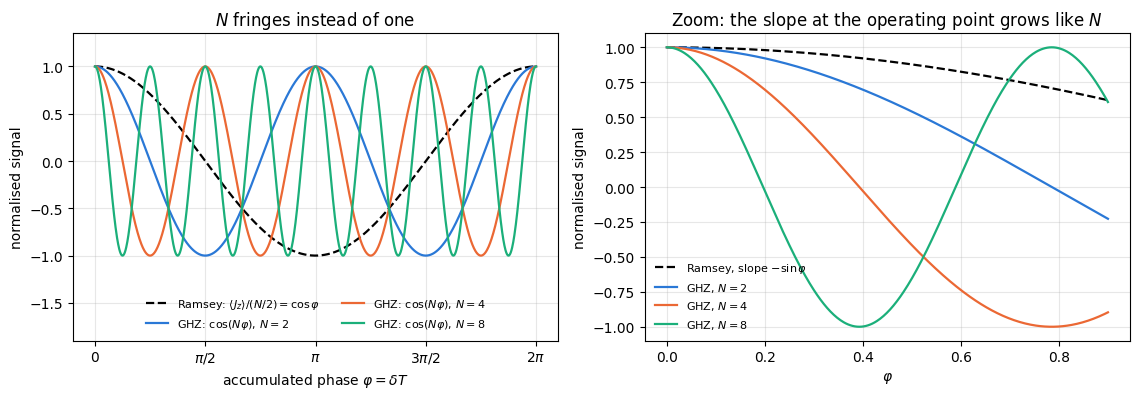

In [7]:
# ==============================================================================
# FIGURE 1: the GHZ fringe against the Ramsey fringe
# ==============================================================================
PHI = np.linspace(0, 2 * np.pi, 1200)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))

axes[0].plot(PHI, np.cos(PHI), color="k", lw=1.6, ls="--", label=r"Ramsey: $\langle J_z\rangle/(N/2)=\cos\varphi$")
for i, N in enumerate((2, 4, 8)):
    axes[0].plot(PHI, np.cos(N * PHI), color=PALETTE[i], lw=1.6, label=rf"GHZ: $\cos(N\varphi)$, $N={N}$")
axes[0].set_xlabel(r"accumulated phase $\varphi=\delta T$"); axes[0].set_ylabel("normalised signal")
axes[0].set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
axes[0].set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axes[0].set_title("$N$ fringes instead of one")
axes[0].legend(fontsize=8, loc="lower center", ncol=2)
axes[0].set_ylim(-1.9, 1.35)

zoom = np.linspace(0, 0.9, 400)
axes[1].plot(zoom, np.cos(zoom), color="k", lw=1.6, ls="--", label=r"Ramsey, slope $-\sin\varphi$")
for i, N in enumerate((2, 4, 8)):
    axes[1].plot(zoom, np.cos(N * zoom), color=PALETTE[i], lw=1.6, label=rf"GHZ, $N={N}$")
axes[1].set_xlabel(r"$\varphi$"); axes[1].set_ylabel("normalised signal")
axes[1].set_title(r"Zoom: the slope at the operating point grows like $N$")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The signal amplitude is the same in both protocols; what changes is the **frequency**. At the steepest point of its fringe
the GHZ signal has $N$ times the slope of the Ramsey signal, and squaring that ratio gives $N^2$. Squared slopes are only
half of the Fisher-information bookkeeping, though: the plotted Ramsey signal is the *average* of $N$ atoms, so one
repetition of it has variance $\sin^2\varphi/N$, while one repetition of the GHZ protocol is a single bounded $\pm1$ parity
bit of variance $\sin^2(N\varphi)$ — $N$ times more. Dividing the $N^2$ from the slopes by that $N$ leaves exactly the
factor $N$ between $F_Q=N$ and $F_Q=N^2$. (Check: $F=(\partial_\varphi s)^2/\mathrm{Var}(s)$ gives
$\sin^2\varphi/(\sin^2\varphi/N)=N$ for Ramsey and $N^2\sin^2(N\varphi)/\sin^2(N\varphi)=N^2$ for GHZ.) The right
panel also shows the price: the first zero crossing moves from $\varphi=\pi/2$ to $\varphi=\pi/(2N)$.

## 7. Simulated records and the estimator

### 7.1 Sampling

The honest simulation measures all $N$ atoms in the $X$ basis with the engine's `sample_bitstrings` (which rotates each axis
and draws from the Born distribution over all $2^N$ strings) and forms the parity
$\pi=\prod_q(1-2s_q)$. Equation (7) says the result is a single Bernoulli variable with $p_+=(1+\cos N\varphi)/2$, so for the
large sweeps we may sample that Bernoulli directly — after checking the equivalence, exactly as in
[notebook 31](./31_ramsey_interferometry.ipynb).

### 7.2 Estimator

The log-likelihood of $k$ "$+1$" outcomes out of $M$ is $k\ln p_++(M-k)\ln p_-$; setting its derivative to zero gives
$p_+(\hat\varphi)=k/M$, so maximum likelihood and method of moments again coincide (the parity count is sufficient) and

$$\hat\varphi=\frac1N\arccos\Big(\frac{2k/M-1}{C}\Big), \tag{12}$$

with $C$ the fringe contrast ($C=1$ for the ideal protocol). The $\arccos$ is restricted to $[0,\pi]$, so $\hat\varphi$ lives
in $[0,\pi/N]$ — the unambiguous window, which is Section 9's subject. We operate at its centre,
$\varphi_{\mathrm{true}}=\pi/(2N)$, the mid-fringe point where Eq. (11) is largest for any $C<1$ as well.

In [8]:
# ==============================================================================
# STEP 4: sampling the parity record, two ways, and checking they agree
# ==============================================================================
def parity_from_bits(bits):
    """Parity of an X-basis record: pi = prod_q (-1)^{s_q}, mapped to {+1,-1}."""
    return jnp.prod(1 - 2 * bits, axis=-1)


@partial(jax.jit, static_argnames=("N", "shots"))
def parity_record_engine(key, phi, N, shots):
    """`shots` full N-atom records measured in the X basis; returns the parity of each (+-1).
    COST  the categorical sampler allocates shots x 2^N numbers -- use only for moderate N and shots."""
    return parity_from_bits(sample_bitstrings(key, ghz_encoded(N, phi), shots, bases="X" * N))


@partial(jax.jit, static_argnames=("shots", "n_exp"))
def parity_counts(key, phi, N, shots, n_exp, contrast=1.0):
    """Number of +1 parity outcomes in each of `n_exp` independent experiments of `shots` repetitions.
    MATH  the parity is a single Bernoulli variable with p_+ = (1 + C cos(N phi))/2  [Eq. (8)];
          the N bits of a record are uniform within each parity class, so nothing else is needed.
    JAX   `N` may be traced here: it enters only through cos(N phi), not through an array shape."""
    p_plus = (1 + contrast * jnp.cos(N * phi)) / 2
    return jnp.sum(jax.random.bernoulli(key, p_plus, (n_exp, shots)), axis=1)


# --- CHECKPOINT: engine sampler vs Bernoulli sampler; uniformity inside a parity class ----------------
SHOTS_CHK = 40000
print(f"{'N':>4s} {'phi':>7s} {'<P> engine':>12s} {'<P> Bernoulli':>14s} {'cos(N phi)':>12s} "
      f"{'z-score':>9s} {'flatness inside class':>22s}")
for N in (3, 4, 6):
    for phi in (0.25, np.pi / (2 * N)):
        ka, kb = jax.random.split(jax.random.PRNGKey(17 * N + int(100 * phi)))
        par = np.asarray(parity_record_engine(ka, float(phi), N, SHOTS_CHK), float)
        k = int(parity_counts(kb, float(phi), float(N), SHOTS_CHK, 1)[0])
        a, b = par.mean(), 2 * k / SHOTS_CHK - 1
        se = np.sqrt((par.var(ddof=1) + (1 - b ** 2)) / SHOTS_CHK)
        # flatness: relative spread of the string frequencies inside the even-parity class
        bits = np.asarray(sample_bitstrings(ka, ghz_encoded(N, float(phi)), SHOTS_CHK, bases="X" * N))
        idx = bits @ (2 ** np.arange(N - 1, -1, -1))
        cnt = np.bincount(idx, minlength=2 ** N)
        even = cnt[[i for i in range(2 ** N) if bin(i).count("1") % 2 == 0]]
        flat = (even.max() - even.min()) / even.mean()
        print(f"{N:4d} {phi:7.4f} {a:12.5f} {b:14.5f} {np.cos(N * phi):12.5f} {(a - b) / se:9.3f} {flat:22.4f}")
        assert abs(a - b) < 4 * se

   N     phi   <P> engine  <P> Bernoulli   cos(N phi)   z-score  flatness inside class


   3  0.2500      0.73295        0.73295      0.73169     0.000                 0.0185
   3  0.5236      0.00145       -0.00375      0.00000     0.735                 0.0296


   4  0.2500      0.53835        0.53760      0.54030     0.126                 0.0395
   4  0.3927     -0.00340       -0.00085      0.00000    -0.361                 0.0397


   6  0.2500      0.07020        0.07100      0.07074    -0.113                 0.1809
   6  0.2618     -0.00260        0.00685      0.00000    -1.336                 0.1684


All $z$-scores are below $1.4$, so the two samplers are statistically indistinguishable. The last column is the relative
spread of the string frequencies inside one parity class: $0.019$ at $N=3$, rising to $0.18$ at $N=6$ — exactly what
$\sqrt{\text{counts}}$ fluctuations give when $40\,000$ samples are divided among $4$ and then among $32$ equally likely
strings. The record is flat inside each class, as Eq. (7) demands, so the parity is the only thing worth keeping. From here
on we use the Bernoulli sampler.

> **Common pitfall.** The one-bit shortcut is legitimate for a *different* reason than the one in
> [notebook 31](./31_ramsey_interferometry.ipynb). There the $N$ bits of a record were **independent**, because the state
> was a product; here they are maximally **correlated**, and only their product is a random variable with a
> $\varphi$-dependent law. Sampling $N$ independent coins would be flatly wrong for a GHZ probe. What licenses the shortcut
> is the sufficiency of the parity, derived in Eq. (7) and tested in the cell above — not any independence.

> **JAX practice.** `parity_counts` takes the atom number `N` as a *traced* argument while `parity_record_engine` needs it
> *static*. The rule is mechanical: a value that determines an array **shape** or an einsum **string** must be static; a
> value that only enters arithmetic may be traced. In `parity_counts`, $N$ appears only inside $\cos(N\varphi)$, so one
> compiled program serves every atom number and the sweep of Section 8 compiles once.

In [9]:
# ==============================================================================
# STEP 5: K independent experiments -- histogram of the estimate, bias, measured Delta phi
# ==============================================================================
def phi_hat_parity(k, N, shots, contrast=1.0):
    """Estimator (12): invert p_+ = (1 + C cos(N phi))/2 from the count k of +1 outcomes."""
    return jnp.arccos(jnp.clip((2 * k / shots - 1) / contrast, -1.0, 1.0)) / N


N_H, M_H, K_H = 8, 400, 12000
phi_true_H = np.pi / (2 * N_H)
k_H = parity_counts(jax.random.PRNGKey(2026), phi_true_H, float(N_H), M_H, K_H)
est_H = np.asarray(phi_hat_parity(k_H, N_H, M_H))

crb_H = 1.0 / (N_H * np.sqrt(M_H))
sql_H = 1.0 / np.sqrt(N_H * M_H)
print(f"N = {N_H} atoms, M = {M_H} repetitions, K = {K_H} independent experiments")
print(f"  operating point phi_true = pi/(2N) = {phi_true_H:.6f}")
print(f"  mean estimate           = {est_H.mean():.6f}")
print(f"  bias                    = {est_H.mean() - phi_true_H:+.2e}  +- {est_H.std(ddof=1) / np.sqrt(K_H):.2e}")
print(f"  measured Delta phi      = {est_H.std(ddof=1):.6f}  +- {float(std_of_std(est_H.std(ddof=1), K_H)):.6f}")
print(f"  Heisenberg 1/(N sqrt M) = {crb_H:.6f}       ratio = {est_H.std(ddof=1) / crb_H:.4f}")
print(f"  SQL        1/sqrt(N M)  = {sql_H:.6f}       gain over SQL = {sql_H / est_H.std(ddof=1):.4f}  "
      f"(sqrt(N) = {np.sqrt(N_H):.4f})")
assert 0.9 < est_H.std(ddof=1) / crb_H < 1.12

N = 8 atoms, M = 400 repetitions, K = 12000 independent experiments
  operating point phi_true = pi/(2N) = 0.196350
  mean estimate           = 0.196380
  bias                    = +3.06e-05  +- 5.66e-05
  measured Delta phi      = 0.006197  +- 0.000040
  Heisenberg 1/(N sqrt M) = 0.006250       ratio = 0.9915
  SQL        1/sqrt(N M)  = 0.017678       gain over SQL = 2.8526  (sqrt(N) = 2.8284)


At $N=8$ and $M=400$ the measured $\Delta\varphi=0.006197$ sits on the Heisenberg value $1/(N\sqrt M)=0.006250$ (ratio
$0.9915$), the bias is $3.1\cdot10^{-5}$ against a statistical error of $5.7\cdot10^{-5}$ on the mean, and the gain over the
standard quantum limit at the same $N$ and $M$ is $2.85$, to be compared with $\sqrt8=2.83$. The estimator is unbiased at
mid-fringe and saturates the bound (5).

## 8. The scaling: Heisenberg against the standard quantum limit

One point is not a scaling law. We sweep $N$ at fixed $M$ for both protocols, each experiment repeated $K$ times so that the
standard deviation of $\hat\varphi$ is *measured* and carries its own error bar, and fit the exponent. Both protocols use
the same $N$ atoms and the same $M$ repetitions, so the comparison is at equal resources. The Ramsey estimator and sampler
are those of [notebook 31](./31_ramsey_interferometry.ipynb), reproduced here in three lines.

In [10]:
# ==============================================================================
# STEP 6: GHZ vs Ramsey -- measured Delta phi against N at fixed M
# ==============================================================================
@partial(jax.jit, static_argnames=("N", "shots", "n_exp"))
def ramsey_counts(key, phi, N, shots, n_exp, contrast=1.0):
    """Notebook 31: N independent atoms, each excited with probability (1 - C cos phi)/2;
    returns the total number of excited detections in each of `n_exp` experiments."""
    p = (1 - contrast * jnp.cos(phi)) / 2
    return jnp.sum(jax.random.bernoulli(key, p, (n_exp, shots, N)), axis=(1, 2))


def phi_hat_ramsey(k, N, shots, contrast=1.0):
    """Notebook 31, Eq. (14): phi_hat = arccos[(1 - 2 k/(N M))/C]."""
    return jnp.arccos(jnp.clip((1 - 2 * k / (N * shots)) / contrast, -1.0, 1.0))


N_LIST = [2, 3, 4, 6, 8, 11, 16]
M_SC, K_SC = 400, 8000
sig_ghz, err_ghz, sig_ram, err_ram = [], [], [], []
key = jax.random.PRNGKey(7)
for N in N_LIST:
    key, k1, k2 = jax.random.split(key, 3)
    kg = parity_counts(k1, np.pi / (2 * N), float(N), M_SC, K_SC)
    sg = float(np.std(np.asarray(phi_hat_parity(kg, N, M_SC)), ddof=1))
    kr = ramsey_counts(k2, np.pi / 2, N, M_SC, K_SC)
    sr = float(np.std(np.asarray(phi_hat_ramsey(kr, N, M_SC)), ddof=1))
    sig_ghz.append(sg); err_ghz.append(float(std_of_std(sg, K_SC)))
    sig_ram.append(sr); err_ram.append(float(std_of_std(sr, K_SC)))

A_g, s_g = fit_power_law(N_LIST, sig_ghz)
A_r, s_r = fit_power_law(N_LIST, sig_ram)
print(f"M = {M_SC} repetitions, K = {K_SC} independent experiments per point, both at mid-fringe\n")
print(f"{'N':>4s} {'GHZ measured':>14s} {'error':>9s} {'1/(N sqrt M)':>13s} {'ratio':>7s} | "
      f"{'Ramsey measured':>16s} {'error':>9s} {'1/sqrt(NM)':>11s} {'ratio':>7s} | {'gain':>6s} {'sqrt(N)':>8s}")
for N, sg, eg, sr, er in zip(N_LIST, sig_ghz, err_ghz, sig_ram, err_ram):
    hb, sq = 1 / (N * np.sqrt(M_SC)), 1 / np.sqrt(N * M_SC)
    print(f"{N:4d} {sg:14.6f} {eg:9.6f} {hb:13.6f} {sg / hb:7.4f} | {sr:16.6f} {er:9.6f} {sq:11.6f} "
          f"{sr / sq:7.4f} | {sr / sg:6.3f} {np.sqrt(N):8.3f}")
print(f"\nfitted exponents:  GHZ {s_g:+.4f} (expected -1)      Ramsey {s_r:+.4f} (expected -0.5)")
assert abs(s_g + 1.0) < 0.06 and abs(s_r + 0.5) < 0.06

M = 400 repetitions, K = 8000 independent experiments per point, both at mid-fringe

   N   GHZ measured     error  1/(N sqrt M)   ratio |  Ramsey measured     error  1/sqrt(NM)   ratio |   gain  sqrt(N)
   2       0.024901  0.000197      0.025000  0.9960 |         0.035344  0.000279    0.035355  0.9997 |  1.419    1.414
   3       0.016752  0.000132      0.016667  1.0051 |         0.028770  0.000227    0.028868  0.9966 |  1.717    1.732
   4       0.012571  0.000099      0.012500  1.0057 |         0.025035  0.000198    0.025000  1.0014 |  1.991    2.000
   6       0.008381  0.000066      0.008333  1.0057 |         0.020403  0.000161    0.020412  0.9995 |  2.434    2.449
   8       0.006172  0.000049      0.006250  0.9875 |         0.017879  0.000141    0.017678  1.0114 |  2.897    2.828
  11       0.004537  0.000036      0.004545  0.9981 |         0.015078  0.000119    0.015076  1.0002 |  3.324    3.317
  16       0.003114  0.000025      0.003125  0.9964 |         0.012596  0.000100  

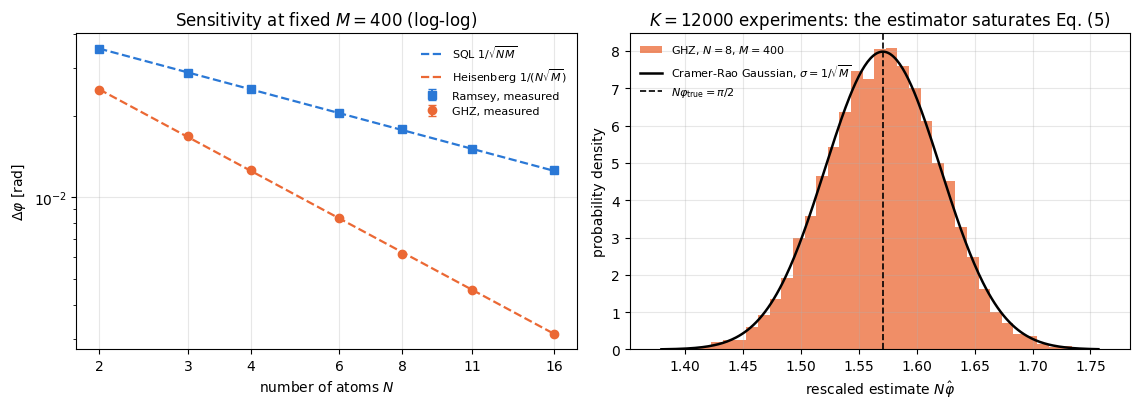

In [11]:
# ==============================================================================
# FIGURE 2: the two scaling laws, measured
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
nn = np.linspace(min(N_LIST), max(N_LIST), 100)

axes[0].errorbar(N_LIST, sig_ram, yerr=err_ram, fmt="s", color=PALETTE[0], ms=6, capsize=3,
                 label="Ramsey, measured")
axes[0].plot(nn, 1 / np.sqrt(nn * M_SC), color=PALETTE[0], lw=1.6, ls="--",
             label=r"SQL $1/\sqrt{NM}$")
axes[0].errorbar(N_LIST, sig_ghz, yerr=err_ghz, fmt="o", color=PALETTE[1], ms=6, capsize=3,
                 label="GHZ, measured")
axes[0].plot(nn, 1 / (nn * np.sqrt(M_SC)), color=PALETTE[1], lw=1.6, ls="--",
             label=r"Heisenberg $1/(N\sqrt{M})$")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
# integer tick labels: a log axis would otherwise print "2 x 10^0" for two atoms
axes[0].set_xticks(N_LIST); axes[0].set_xticklabels([str(N) for N in N_LIST])
axes[0].set_xticks([], minor=True)
axes[0].set_xlabel(r"number of atoms $N$"); axes[0].set_ylabel(r"$\Delta\varphi$ [rad]")
axes[0].set_title(rf"Sensitivity at fixed $M={M_SC}$ (log-log)")
axes[0].legend(fontsize=8)

# the estimate is a function of the INTEGER parity count, so it takes only discrete values:
# put the bin edges half-way between consecutive attainable values (two per bin)
k_edges = np.arange(int(k_H.min()) - 1, int(k_H.max()) + 3, 2) - 0.5
edges = np.asarray(phi_hat_parity(jnp.asarray(k_edges, dtype=RDTYPE), N_H, M_H)) * N_H
axes[1].hist(est_H * N_H, bins=np.sort(edges), density=True, color=PALETTE[1], alpha=0.75,
             label=rf"GHZ, $N={N_H}$, $M={M_H}$")
xx = np.linspace((est_H * N_H).min(), (est_H * N_H).max(), 300)
axes[1].plot(xx, np.exp(-(xx - phi_true_H * N_H) ** 2 / (2 * (1 / np.sqrt(M_H)) ** 2))
             / np.sqrt(2 * np.pi / M_H), color="k", lw=1.8,
             label=r"Cramer-Rao Gaussian, $\sigma=1/\sqrt{M}$")
axes[1].axvline(phi_true_H * N_H, color="k", ls="--", lw=1.2, label=r"$N\varphi_{\mathrm{true}}=\pi/2$")
axes[1].set_xlabel(r"rescaled estimate $N\hat\varphi$"); axes[1].set_ylabel("probability density")
axes[1].set_title(r"$K=%d$ experiments: the estimator saturates Eq. (5)" % K_H)
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

**Left.** Two straight lines of different slope on a log-log plot, each sitting on its own theoretical curve: the fitted
exponents are $-1.0031$ (GHZ) and $-0.4958$ (Ramsey), against $-1$ and $-1/2$. Every measured point is within about one per
cent of its own bound. At $N=16$ the entangled probe is better by a factor $4.045$, against $\sqrt{16}=4$. This is the
Heisenberg limit measured from sampled data rather than asserted.

**Right.** The distribution of $N\hat\varphi$ at $N=8$ collapses onto the same Gaussian of width $1/\sqrt M$ for any $N$ —
which is the content of Eq. (10): the *rescaled* phase $N\varphi$ is estimated with a precision that does not depend on $N$
at all, while the physical phase inherits the factor $1/N$.

## 9. The $2\pi/N$ ambiguity

The signal $\cos(N\varphi)$ is invariant under

$$\varphi\to-\varphi,\qquad \varphi\to\varphi+\frac{2\pi}{N},$$

and these two generate a group of $2N$ transformations of the circle: the $N$ translations by multiples of $2\pi/N$ and the
$N$ reflections obtained by composing them with $\varphi\to-\varphi$. A generic phase therefore has an orbit of $2N$ points,
the likelihood has $2N$ equally high maxima inside $[0,2\pi)$ (they merge pairwise into $N$ only at the fringe extrema
$N\varphi=0,\pi$, where the reflection fixes the point), and a fundamental domain — the unambiguous window — has width
$\pi/N$. The corresponding count for the Ramsey fringe $\cos\varphi$ is $2$ maxima in $[0,2\pi)$ and a window $[0,\pi]$, so
the *ratio* of the two windows is $N$: what matters below. Compared with
the width $\pi$ of the Ramsey window ([notebook 31](./31_ramsey_interferometry.ipynb), Section 14), the range has shrunk by
exactly the factor $N$ by which the fringe was accelerated — and that is the same factor $N$ by which the GHZ probe's own
resolution $\Delta\varphi=1/(N\sqrt M)$ improved. The product (resolution $\times$ range) $=\pi\sqrt M$ is therefore
independent of $N$: entanglement redistributes it, it does not create it. (Against the $N$-atom Ramsey protocol the net
gain in $\Delta\varphi$ is only $\sqrt N$, because those $N$ atoms average; the ambiguity, however, costs the full $N$.)

For a clock this is a serious obstacle. Translating to frequencies, the GHZ interferometer determines the detuning only
modulo $2\pi/(NT)$, so the prior uncertainty on $\delta$ must already be smaller than that before the first measurement is
taken. In practice one uses a **hierarchy of interrogation times**: a first stage with small $T$ (or with unentangled atoms)
localises $\delta$ inside the window of the next stage, which localises it inside the window of the next, and so on. Each
stage spends a fraction of the total time, and the analysis of how to divide that time optimally is the subject of adaptive
and phase-estimation-algorithm protocols (Higgins and co-workers 2007 realised such a ladder with *single* photons passed
through the phase shift $2^k$ times, reaching Heisenberg scaling with no entanglement at all; Kessler and co-workers 2014
apply the same idea to entangled clocks). A single Heisenberg-limited measurement is useless without that scaffolding; what
it provides is the *final* refinement, and only in the regime where its window has already been earned.

The cell below shows the aliasing explicitly: two true phases separated by $2\pi/N$ produce statistically identical records.

In [12]:
# ==============================================================================
# STEP 7: aliasing -- two phases that no number of shots can separate
# ==============================================================================
N_AL, M_AL, K_AL = 6, 2000, 4000
phi_a = np.pi / (2 * N_AL)
phi_b = phi_a + 2 * np.pi / N_AL
ka, kb = jax.random.split(jax.random.PRNGKey(88))
ka_ = np.asarray(parity_counts(ka, phi_a, float(N_AL), M_AL, K_AL), float)
kb_ = np.asarray(parity_counts(kb, phi_b, float(N_AL), M_AL, K_AL), float)
se = np.sqrt(ka_.var(ddof=1) / K_AL + kb_.var(ddof=1) / K_AL)
print(f"N = {N_AL}:  phi_a = {phi_a:.6f},  phi_b = phi_a + 2 pi/N = {phi_b:.6f}")
print(f"  cos(N phi_a) = {np.cos(N_AL * phi_a):+.12f}")
print(f"  cos(N phi_b) = {np.cos(N_AL * phi_b):+.12f}   (identical: the two records have the same law)")
print(f"  mean parity count out of M = {M_AL}:  {ka_.mean():.3f} vs {kb_.mean():.3f}, "
      f"z-score of the difference = {(ka_.mean() - kb_.mean()) / se:+.3f}")
print(f"  both estimators report phi_hat = {float(phi_hat_parity(jnp.mean(ka_), N_AL, M_AL)):.6f} "
      f"(the window is [0, pi/N] = [0, {np.pi / N_AL:.4f}])")
assert abs(np.cos(N_AL * phi_a) - np.cos(N_AL * phi_b)) < 1e-12

N = 6:  phi_a = 0.261799,  phi_b = phi_a + 2 pi/N = 1.308997
  cos(N phi_a) = +0.000000000000
  cos(N phi_b) = +0.000000000000   (identical: the two records have the same law)
  mean parity count out of M = 2000:  1000.157 vs 1000.417, z-score of the difference = -0.517
  both estimators report phi_hat = 0.261773 (the window is [0, pi/N] = [0, 0.5236])


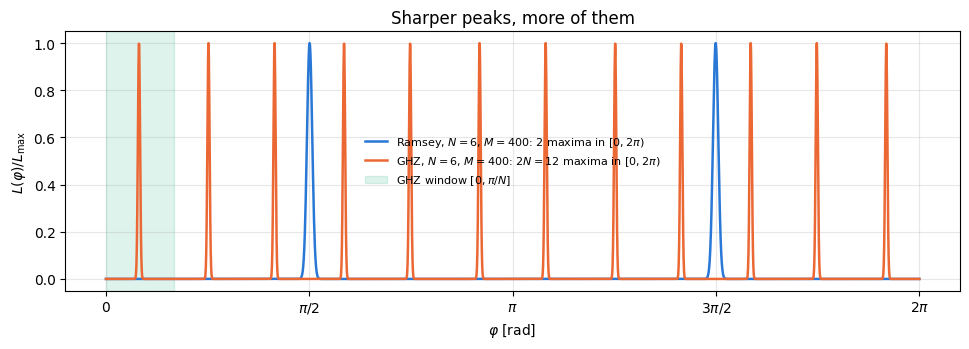

In [13]:
# ==============================================================================
# FIGURE 3: the likelihood of one GHZ data set, and of one Ramsey data set
# ==============================================================================
def loglik_parity(phi, k, shots, N, contrast=1.0):
    """ln L = k ln p_+ + (M-k) ln p_- with p_+- = (1 +- C cos(N phi))/2."""
    p = jnp.clip((1 + contrast * jnp.cos(N * phi)) / 2, 1e-12, 1 - 1e-12)
    return k * jnp.log(p) + (shots - k) * jnp.log(1 - p)


phi_grid = jnp.linspace(0.0, 2 * np.pi, 4000)
N_LL, M_LL = 6, 400
k_ll = int(parity_counts(jax.random.PRNGKey(5), np.pi / (2 * N_LL), float(N_LL), M_LL, 1)[0])
ll_ghz = np.array(jax.vmap(lambda p: loglik_parity(p, k_ll, M_LL, N_LL))(phi_grid))
ll_ghz = ll_ghz - ll_ghz.max()
k_r = int(ramsey_counts(jax.random.PRNGKey(6), np.pi / 2, N_LL, M_LL, 1)[0])
ll_ram = np.array(jax.vmap(lambda p: loglik_parity(p, N_LL * M_LL - k_r, N_LL * M_LL, 1))(phi_grid))
ll_ram = ll_ram - ll_ram.max()

fig, ax = plt.subplots(figsize=(9.8, 3.6))
ax.plot(np.asarray(phi_grid), np.exp(ll_ram), color=PALETTE[0], lw=1.8,
        label=rf"Ramsey, $N={N_LL}$, $M={M_LL}$: 2 maxima in $[0,2\pi)$")
ax.plot(np.asarray(phi_grid), np.exp(ll_ghz), color=PALETTE[1], lw=1.8,
        label=rf"GHZ, $N={N_LL}$, $M={M_LL}$: $2N={2 * N_LL}$ maxima in $[0,2\pi)$")
ax.axvspan(0, np.pi / N_LL, color=PALETTE[2], alpha=0.15, label=r"GHZ window $[0,\pi/N]$")
ax.set_xlabel(r"$\varphi$ [rad]"); ax.set_ylabel(r"$L(\varphi)/L_{\max}$")
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_title("Sharper peaks, more of them")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The GHZ likelihood peaks are narrower than the Ramsey peak by a factor $N$ — that is the metrological gain — and there are
$2N=12$ of them against the Ramsey curve's $2$. Any data set is compatible with $2N$ different phases, and choosing among
them is not a statistical problem but a question of what was known beforehand. (Counting *maxima* and counting *fringes*
are different: the signal $\cos(N\varphi)$ has $N$ maxima per $2\pi$, but a measured value strictly between $-1$ and $+1$
is attained twice per fringe, once on the rising and once on the falling flank.)

> **Physics insight.** Resolution and range trade off exactly. One GHZ window of width $\pi/N$ holds
> $(\pi/N)\cdot N\sqrt M=\pi\sqrt M$ distinguishable phases, which is exactly what a **single** atom measured $M$ times
> holds in its own window of width $\pi$: the factor $N$ multiplies the resolution and divides the range, and their
> product does not move. The interferometer behaves as one super-atom, not as $N$ atoms. The Ramsey window of width $\pi$
> holds $\pi\sqrt{NM}$ phases instead — a factor $\sqrt N$ **more**, because $N$ independent atoms genuinely average.
> What the GHZ probe buys is a finer grid, usable only inside a window that prior knowledge must supply; the $\sqrt N$ it
> gains in $\Delta\varphi$ over the Ramsey protocol is paid for with an $N$-fold ambiguity. Entanglement redistributes the
> interferometer's dynamic range towards resolution; it does not manufacture information out of nothing, which is why
> Section 13 finds no free lunch once the range must also be earned.

## 10. Decoherence during the interrogation: closed forms

Three single-qubit channels act independently on each atom during the interrogation. All three **commute** with the encoding
$e^{-i\varphi J_z}=\bigotimes R_z(\varphi)$, so "noise during the interrogation" and "noise after it" are the same map and no
Trotterisation is needed:

* dephasing and its Kraus operators $\{\sqrt{1-p}\,\mathbb 1,\sqrt p\,Z\}$ are diagonal, hence commute with $R_z$;
* depolarising in the form $\rho\mapsto\lambda\rho+(1-\lambda)\tfrac{\mathbb 1}{2}$ with $\lambda=1-\tfrac{4p}{3}$ is
  covariant under *every* single-qubit unitary;
* for amplitude damping, $K_0=\mathrm{diag}(1,\sqrt{1-g})$ commutes with $R_z$ and
  $R_zK_1R_z^\dagger=e^{-i\varphi}K_1$, a phase that drops out of $K\rho K^\dagger$.

### 10.1 Contrasts

The parity signal is the $N$-body coherence, $\langle X^{\otimes N}\rangle=2\,\mathrm{Re}\,\rho_{\bar1\bar0}$, and
[notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb) derives what each channel does to
it. Collecting those results, the fringe keeps its shape and loses contrast:

$$\langle P\rangle(\varphi)=C\cos(N\varphi),\qquad
C_{\text{deph}}=(1-2p)^N,\quad C_{\text{depol}}=\lambda^N,\quad C_{\text{damp}}=(1-g)^{N/2}. \tag{13}$$

Each is the $N$-th power of a single-atom factor, because the coherence $\rho_{\bar0\bar1}$ connects two basis states that
differ on **every** atom. For dephasing the identification with a rate follows exactly as in
[notebook 31](./31_ramsey_interferometry.ipynb): $p=\tfrac12(1-e^{-\gamma T})$ gives $1-2p=e^{-\gamma T}$ and

$$C_{\text{deph}}=e^{-N\gamma T}. \tag{14}$$

**The GHZ coherence decays $N$ times faster than a single atom's.** That single sentence is the whole tension of this
notebook: the same factor $N$ appears in the gain and in the decay.

### 10.2 Sensitivity from the parity measurement

With contrast $C$, the outcome distribution is $p_\pm=(1\pm C\cos N\varphi)/2$ and the classical Fisher information is

$$F(\varphi)=\frac{N^2C^2\sin^2(N\varphi)}{1-C^2\cos^2(N\varphi)},\qquad \max_\varphi F=N^2C^2\ \text{ at }\ N\varphi=\frac\pi2,$$

(the same expression as notebook 31's noisy Ramsey fringe with $\varphi\to N\varphi$ and an extra $N^2$; the maximum
follows the same way: writing $u=\cos N\varphi$, $\partial_uF\propto-u(1-C^2)$, so the extremum is at $u=0$). At the
operating point,

$$\Delta\varphi=\frac{1}{NC\sqrt M}. \tag{15}$$

### 10.3 Quantum Fisher information under dephasing

Dephasing is special: every Kraus operator $Z_S$ (a $Z$ on a subset $S$ of atoms) maps $\vert\bar0\rangle$ and
$\vert\bar1\rangle$ to themselves up to a sign, so the state **never leaves** the two-dimensional subspace
$\mathrm{span}\{\vert\bar0\rangle,\vert\bar1\rangle\}$:

$$\rho=\frac12\big(\vert\bar0\rangle\langle\bar0\vert+\vert\bar1\rangle\langle\bar1\vert\big)
+\frac C2\big(e^{-iN\varphi}\vert\bar0\rangle\langle\bar1\vert+\text{h.c.}\big).$$

Inside that subspace the state is an effective qubit with Bloch vector $\mathbf r=(C\cos N\varphi,\ C\sin N\varphi,\ 0)$
(from $\rho_{\bar0\bar1}=\tfrac12(r_x-ir_y)=\tfrac C2e^{-iN\varphi}$),
and the generator $J_z$ acts as $\tfrac N2\sigma_z^{\mathrm{eff}}$ — that is, $N$ times the generator of notebook 31,
Section 15.3, whose quantum Fisher information was $r_\perp^2$. Quantum Fisher information is quadratic in the generator,
so

$$F_Q=N^2C^2=N^2e^{-2N\gamma T}. \tag{16}$$

Comparing with Eq. (15): the parity measurement still saturates the bound under dephasing.

### 10.4 Depolarising and damping: parity is no longer optimal

Neither of the other two channels preserves the two-dimensional subspace — some of the population leaks out of
$\mathrm{span}\{\vert\bar0\rangle,\vert\bar1\rangle\}$ — but the structure survives, and with it a closed form. Three
observations do all the work.

1. **No new coherences appear.** A local channel maps the operator $\vert0\rangle\langle1\vert$ to a multiple of itself for
   all three channels: for dephasing and damping by inspection of the Kraus operators, and for depolarising because
   $\rho\mapsto\lambda\rho+(1-\lambda)\mathrm{Tr}(\rho)\tfrac{\mathbb 1}{2}$ and $\mathrm{Tr}\vert0\rangle\langle1\vert=0$,
   so $\vert0\rangle\langle1\vert\mapsto\lambda\vert0\rangle\langle1\vert$. The diagonal parts stay diagonal. Hence the
   noisy state is **diagonal in the computational basis apart from the single coherence**
   $\rho_{\bar0\bar1}=\tfrac C2e^{-iN\varphi}$.
2. **Only that one $2\times2$ block carries $\varphi$, and only it contributes to $F_Q$.** The generator $J_z$ is diagonal,
   so $\langle m\vert J_z\vert n\rangle=0$ between any two computational basis states; the only off-diagonal matrix elements
   of $J_z$ in the eigenbasis of $\rho$ are the ones inside the $\{\vert\bar0\rangle,\vert\bar1\rangle\}$ block. Writing
   $t=\rho_{\bar0\bar0}+\rho_{\bar1\bar1}$ for the weight that block still carries, its two eigenvalues are
   $\tfrac t2(1\pm r)$ with $r=\vert\mathbf r\vert$, $r_\perp=C/t$, and Eq. (2) collapses to

$$F_Q=t\,N^2r_\perp^2=\frac{N^2C^2}{t}. \tag{16a}$$

3. **Parity sees $t<1$ as a loss of contrast, not as a flag.** The leaked population is diagonal and has no
   $\vert s\rangle\langle\bar s\vert$ coherence, so it contributes $\pm1$ to $X^{\otimes N}$ with probability $\tfrac12$
   each: a $\varphi$-independent background. The parity distribution is $p_\pm=(1\pm C\cos N\varphi)/2$ with
   $F=N^2C^2$ at mid-fringe, against $F_Q=N^2C^2/t$.

The ratio is therefore exactly

$$\frac{F_Q}{N^2C^2}=\frac1t,$$

with the three closed forms

$$t_{\text{deph}}=1,\qquad t_{\text{depol}}=\Big(\frac{1+\lambda}{2}\Big)^{\!N}+\Big(\frac{1-\lambda}{2}\Big)^{\!N},\qquad
t_{\text{damp}}=\frac{1+g^N+(1-g)^N}{2}, \tag{16b}$$

obtained by pushing the two populations through the single-atom channel ($\vert0\rangle$ survives damping, $\vert1\rangle$
decays with probability $g$ per atom). Dephasing has $t=1$: nothing leaks, and Eq. (16a) reduces to Eq. (16).

This also names the **better measurement**, and it is not an exotic one. The three-outcome readout

$$E_\pm=\vert G_\pm\rangle\langle G_\pm\vert\ \text{ with }\ \vert G_\pm\rangle=\frac{\vert\bar0\rangle\pm\vert\bar1\rangle}
{\sqrt2},\qquad E_{\mathrm{out}}=\mathbb 1-E_+-E_-$$

has $p_\pm=(t\pm C\cos N\varphi)/2$, $p_{\mathrm{out}}=1-t$, and classical Fisher information
$N^2C^2t\sin^2(N\varphi)/(t^2-C^2\cos^2 N\varphi)$, which at mid-fringe equals $N^2C^2/t=F_Q$ exactly. It is the decoding
circuit of Section 6.3 followed by reading **all** $N$ atoms instead of one: $U_G^\dagger\vert G_\pm\rangle
=\vert0\rangle$ or $\vert1\rangle$ on atom $0$ *and* $\vert0\rangle$ on all the others, so the extra $N-1$ detectors do
nothing but announce whether the run stayed inside the GHZ subspace. Discarding the runs that did not is what recovers the
factor $1/t$. The measurement does not depend on the noise strength, or on which of the three channels acted.

We check Eqs. (16a)-(16b) against the symmetric-logarithmic-derivative formula (2) evaluated on the density tensor, using
`qfi_mixed` with the dense generator `collective_dense(Z, N)`; the cost is $O(4^N)$ memory and one eigendecomposition of a
$2^N\times2^N$ matrix, so $N\le6$.

In [14]:
# ==============================================================================
# STEP 8: exact noisy GHZ -- contrasts against Eq. (13), QFI against Eq. (16)
# ==============================================================================
CHANNELS = {"dephasing": (kraus_dephasing, lambda p, N: (1 - 2 * p) ** N),
            "depolarising": (kraus_depolarizing, lambda p, N: (1 - 4 * p / 3) ** N),
            "amplitude damping": (kraus_amplitude_damping, lambda p, N: (1 - p) ** (N / 2))}

# surviving weight of the GHZ subspace, t = rho_0bar0bar + rho_1bar1bar -- Eq. (16b)
SUBSPACE_WEIGHT = {"dephasing": lambda p, N: 1.0,
                   "depolarising": lambda p, N: ((2 - 4 * p / 3) / 2) ** N + ((4 * p / 3) / 2) ** N,
                   "amplitude damping": lambda p, N: (1 + p ** N + (1 - p) ** N) / 2}


def noisy_encoded_dm(N, phi, kraus):
    """Density tensor of the encoded GHZ probe after one local channel on every atom.
    COST  O(4^N) memory; N <= 6 in this notebook."""
    rho = to_dm(ghz_encoded(N, phi))
    for q in range(N):
        rho = apply_kraus_dm(rho, kraus, [q])
    return rho


def qfi_dm(rho_tensor, generator=Z):
    """QFI of a density TENSOR for the collective generator J = (1/2) sum_q P_q, via Eq. (2)."""
    n = rho_tensor.ndim // 2
    return float(qfi_mixed(dm_matrix(rho_tensor), collective_dense(generator, n)))


N_NZ = 4
print(f"N = {N_NZ}.  Contrast from Eq. (13), QFI from Eq. (2), against the parity bound N^2 C^2 and Eq. (16a)\n")
err_c, err_t, err_fq16 = 0.0, 0.0, 0.0
for name, (kr, cf) in CHANNELS.items():
    print(f"{name}:")
    print(f"{'p':>7s} {'C = Eq.(13)':>12s} {'<P>/cos(N phi) exact':>21s} {'QFI (SLD)':>11s} "
          f"{'N^2 C^2 (parity)':>17s} {'QFI / parity':>13s} {'t = Eq.(16b)':>13s} {'t exact':>10s} "
          f"{'N^2C^2/t':>10s}")
    for p in (0.0, 0.05, 0.1, 0.2):
        phi = np.pi / (4 * N_NZ)
        rho = noisy_encoded_dm(N_NZ, phi, kr(p))
        par = float(expect_pauli_string_dm(rho, "X" * N_NZ)) / np.cos(N_NZ * phi)
        C = cf(p, N_NZ)
        fq = qfi_dm(rho)
        rm = dm_matrix(rho)
        t_exact = float(jnp.real(rm[0, 0] + rm[-1, -1]))        # weight left in span{|0bar>, |1bar>}
        t_cf = float(SUBSPACE_WEIGHT[name](p, N_NZ))
        pred = N_NZ ** 2 * C ** 2 / t_cf
        err_c = max(err_c, abs(par - C))
        err_t = max(err_t, abs(t_exact - t_cf))
        err_fq16 = max(err_fq16, abs(fq - pred))
        print(f"{p:7.2f} {C:12.6f} {par:21.9f} {fq:11.6f} {N_NZ ** 2 * C ** 2:17.6f} "
              f"{fq / max(N_NZ ** 2 * C ** 2, 1e-12):13.4f} {t_cf:13.6f} {t_exact:10.6f} {pred:10.6f}")
    print()
print(f"largest deviation of the measured contrast from Eq. (13): {err_c:.2e}")
print(f"largest deviation of the subspace weight from Eq. (16b): {err_t:.2e}")
print(f"largest deviation of the SLD quantum Fisher information from Eq. (16a): {err_fq16:.2e}")
assert err_c < 1e-9 and err_t < 1e-9 and err_fq16 < 1e-9

N = 4.  Contrast from Eq. (13), QFI from Eq. (2), against the parity bound N^2 C^2 and Eq. (16a)

dephasing:
      p  C = Eq.(13)  <P>/cos(N phi) exact   QFI (SLD)  N^2 C^2 (parity)  QFI / parity  t = Eq.(16b)    t exact   N^2C^2/t


   0.00     1.000000           1.000000000   16.000000         16.000000        1.0000      1.000000   1.000000  16.000000
   0.05     0.656100           0.656100000    6.887475          6.887475        1.0000      1.000000   1.000000   6.887475
   0.10     0.409600           0.409600000    2.684355          2.684355        1.0000      1.000000   1.000000   2.684355
   0.20     0.129600           0.129600000    0.268739          0.268739        1.0000      1.000000   1.000000   0.268739

depolarising:
      p  C = Eq.(13)  <P>/cos(N phi) exact   QFI (SLD)  N^2 C^2 (parity)  QFI / parity  t = Eq.(16b)    t exact   N^2C^2/t


   0.00     1.000000           1.000000000   16.000000         16.000000        1.0000      1.000000   1.000000  16.000000
   0.05     0.758835           0.758834568   10.551315          9.213278        1.1452      0.873188   0.873188  10.551315
   0.10     0.564168           0.564167901    6.710862          5.092567        1.3178      0.758854   0.758854   6.710862
   0.20     0.289205           0.289204938    2.370717          1.338232        1.7715      0.564484   0.564484   2.370717

amplitude damping:
      p  C = Eq.(13)  <P>/cos(N phi) exact   QFI (SLD)  N^2 C^2 (parity)  QFI / parity  t = Eq.(16b)    t exact   N^2C^2/t
   0.00     1.000000           1.000000000   16.000000         16.000000        1.0000      1.000000   1.000000  16.000000
   0.05     0.902500           0.902500000   14.364299         13.032100        1.1022      0.907256   0.907256  14.364299
   0.10     0.810000           0.810000000   12.676730         10.497600        1.2076      0.828100   0.828100  12.676

> **Numerical practice.** Each contrast is checked against exact Kraus evolution *before* being used anywhere else. A
> closed form quoted from another notebook is a hypothesis until the simulator agrees with it at the working precision;
> only then may it be substituted into a sweep where an error would be invisible.

The contrasts match Eq. (13) to machine precision for all three channels, and so do the subspace weights and the closed
form (16a): the last three columns are a prediction, not a fit. The `QFI / parity` column compares the quantum Fisher
information with what the parity readout reaches. For dephasing it is $1.0000$ — parity extracts everything, as Eq. (16)
predicts — while for depolarising it climbs to $1.7715$ and for damping to $1.4172$ at $p=0.2$, so the parity measurement
leaves information on the table. Those numbers are not empirical: they are $1/t$ with $t=0.5645$ and $t=0.7056$ from
Eq. (16b).

The reason is structural, and worth stating precisely because the obvious guess is wrong. The escaped population does
**not** carry hidden phase information — it is exactly $\varphi$-independent, as observation 1 of Section 10.4 shows. What
it does is dilute: it contributes an unbiased coin to the parity bit, so a fraction $1-t$ of the runs are pure noise that
the parity readout cannot recognise as such. The three-outcome readout of Section 10.4 recognises them, throws them away,
and thereby reaches $F_Q$ exactly — with the *same* circuit at every noise strength, not with the noise-dependent
eigenbasis of the symmetric logarithmic derivative
([notebook 30](./30_qfi_from_the_sld_prepare_encode_estimate.ipynb)). Exercise 4 checks this.

> **Physics insight.** This is why "parity is the optimal readout for a GHZ probe" is a statement about the *ideal* probe.
> Under dephasing it stays true because nothing leaves the two-dimensional subspace; under any channel that removes weight
> from it, the optimal readout must also ask *whether the probe is still a probe*. The extra $N-1$ detectors of the
> decoding circuit are exactly that question.

## 11. Fragility against the atom number

Equation (13) says the contrast is an $N$-th power, so at fixed per-atom noise the GHZ advantage is destroyed exponentially
fast in $N$. The sensitivity (15) is

$$\Delta\varphi_{\mathrm{GHZ}}=\frac{1}{NC_1^N\sqrt M}\qquad\text{against}\qquad
\Delta\varphi_{\mathrm{SQL}}=\frac{1}{\sqrt{N}\,C_1\sqrt M}$$

for the product state, whose contrast is the single-atom factor $C_1$ (each atom's coherence is attacked once, and the
Ramsey signal is a sum of single-atom coherences — see [notebook 31](./31_ramsey_interferometry.ipynb), Section 15). The GHZ
probe therefore wins only while

$$\frac{1}{NC_1^N}<\frac{1}{\sqrt N C_1}\qquad\Longleftrightarrow\qquad C_1^{\,N-1}>\frac{1}{\sqrt N}
\qquad\Longleftrightarrow\qquad (N-1)\ln\frac{1}{C_1}<\frac12\ln N. \tag{17}$$

For small single-atom damage $\varepsilon=1-C_1\ll1$ the left side is $\simeq(N-1)\varepsilon$, so the advantage survives only
up to $N\simeq1+\ln N/(2\varepsilon)$, whose solution grows like $\varepsilon^{-1}\ln\varepsilon^{-1}$: the usable atom
number is set by the *inverse* of the per-atom damage, up to a logarithm. A per-atom error of one per cent
($\varepsilon=0.01$) already caps it at $N\simeq280$. The cell below evaluates both the quantum Fisher
information and the parity-based sensitivity across a grid of noise strengths and atom numbers.

In [15]:
# ==============================================================================
# STEP 9: QFI and achieved sensitivity vs noise strength and N
# ==============================================================================
P_GRID = np.linspace(0.0, 0.25, 11)
N_GRID = (2, 3, 4, 5, 6)
qfi_tab = {name: np.zeros((len(N_GRID), len(P_GRID))) for name in CHANNELS}
qfi_prod = {name: np.zeros((len(N_GRID), len(P_GRID))) for name in CHANNELS}

t0 = time.time()
for name, (kr, cf) in CHANNELS.items():
    for i, N in enumerate(N_GRID):
        for j, p in enumerate(P_GRID):
            rho_g = noisy_encoded_dm(N, 0.1, kr(float(p)))
            qfi_tab[name][i, j] = qfi_dm(rho_g)
            rho_p = to_dm(collective_pulse(zero_state(N), ry(jnp.pi / 2)))
            for q in range(N):
                rho_p = apply_gate_dm(rho_p, rz(0.1), [q])
            for q in range(N):
                rho_p = apply_kraus_dm(rho_p, kr(float(p)), [q])
            qfi_prod[name][i, j] = qfi_dm(rho_p)
print(f"density-tensor sweep ({len(CHANNELS)} channels x {len(N_GRID)} sizes x {len(P_GRID)} noise values) "
      f"took {time.time() - t0:.1f} s")

print(f"\ndephasing, QFI / N^2 (1 = ideal GHZ, N^{{-1}} = product-state level):")
print(f"{'p':>7s}" + "".join(f"{'N=' + str(N):>10s}" for N in N_GRID))
for j, p in enumerate(P_GRID[::2]):
    jj = 2 * j
    print(f"{p:7.3f}" + "".join(f"{qfi_tab['dephasing'][i, jj] / N ** 2:10.5f}" for i, N in enumerate(N_GRID)))
print(f"\nanalytic check, Eq. (16): QFI/N^2 = (1-2p)^{{2N}}")
print(f"{'p':>7s}" + "".join(f"{'N=' + str(N):>10s}" for N in N_GRID))
for j, p in enumerate(P_GRID[::2]):
    print(f"{p:7.3f}" + "".join(f"{(1 - 2 * p) ** (2 * N):10.5f}" for N in N_GRID))
err_q16 = max(abs(qfi_tab["dephasing"][i, j] - N ** 2 * (1 - 2 * P_GRID[j]) ** (2 * N))
              for i, N in enumerate(N_GRID) for j in range(len(P_GRID)))
print(f"\nlargest deviation from Eq. (16): {err_q16:.2e}")
assert err_q16 < 1e-9


def break_even(ps, ratio):
    """Noise strength at which F_Q/N crosses 1 (linear interpolation on the sampled grid);
    NaN if the curve stays above 1 over the whole grid."""
    r = np.asarray(ratio) - 1.0
    k = np.where(r[:-1] * r[1:] < 0)[0]
    if len(k) == 0:
        return np.nan
    k = int(k[0])
    return float(ps[k] - r[k] * (ps[k + 1] - ps[k]) / (r[k + 1] - r[k]))


print(f"\n(a) break-even against N NOISELESS atoms (F_Q/N = 1):")
print(f"{'channel':>20s}" + "".join(f"{'N=' + str(N):>10s}" for N in N_GRID) + f"{'ln(N)/(4N) for dephasing':>26s}")
for name in CHANNELS:
    be = [break_even(P_GRID, qfi_tab[name][i] / N) for i, N in enumerate(N_GRID)]
    extra = "  " + ", ".join(f"{np.log(N) / (4 * N):.4f}" for N in N_GRID) if name == "dephasing" else ""
    print(f"{name:>20s}" + "".join(f"{b:10.4f}" if np.isfinite(b) else f"{'> 0.25':>10s}" for b in be) + extra)

# The fair comparison uses the product state exposed to the SAME noise -- both arrays are already computed.
print(f"\n(b) break-even against the EQUALLY NOISY product state (F_Q^GHZ / F_Q^product = 1)  <-- Eq. (17):")
print(f"{'channel':>20s}" + "".join(f"{'N=' + str(N):>10s}" for N in N_GRID)
      + f"{'exact (1-N^(-1/(2N-2)))/2, dephasing':>38s}")
for name in CHANNELS:
    be = [break_even(P_GRID, qfi_tab[name][i] / np.maximum(qfi_prod[name][i], 1e-300))
          for i, N in enumerate(N_GRID)]
    extra = "  " + ", ".join(f"{(1 - N ** (-1 / (2 * N - 2))) / 2:.4f}" for N in N_GRID) \
        if name == "dephasing" else ""
    print(f"{name:>20s}" + "".join(f"{b:10.4f}" if np.isfinite(b) else f"{'> 0.25':>10s}" for b in be) + extra)
print("\nexact roots of N (1-2p)^{2N} = 1 (table (a), dephasing):  "
      + ", ".join(f"{(1 - N ** (-1 / (2 * N))) / 2:.4f}" for N in N_GRID)
      + "\n  (the printed values interpolate a convex curve on a grid of step 0.025 and sit 0.3-2% above these roots)")

density-tensor sweep (3 channels x 5 sizes x 11 noise values) took 12.7 s

dephasing, QFI / N^2 (1 = ideal GHZ, N^{-1} = product-state level):
      p       N=2       N=3       N=4       N=5       N=6
  0.000   1.00000   1.00000   1.00000   1.00000   1.00000
  0.050   0.65610   0.53144   0.43047   0.34868   0.28243
  0.100   0.40960   0.26214   0.16777   0.10737   0.06872
  0.150   0.24010   0.11765   0.05765   0.02825   0.01384
  0.200   0.12960   0.04666   0.01680   0.00605   0.00218
  0.250   0.06250   0.01562   0.00391   0.00098   0.00024

analytic check, Eq. (16): QFI/N^2 = (1-2p)^{2N}
      p       N=2       N=3       N=4       N=5       N=6
  0.000   1.00000   1.00000   1.00000   1.00000   1.00000
  0.050   0.65610   0.53144   0.43047   0.34868   0.28243
  0.100   0.40960   0.26214   0.16777   0.10737   0.06872
  0.150   0.24010   0.11765   0.05765   0.02825   0.01384
  0.200   0.12960   0.04666   0.01680   0.00605   0.00218
  0.250   0.06250   0.01562   0.00391   0.00098   0.00

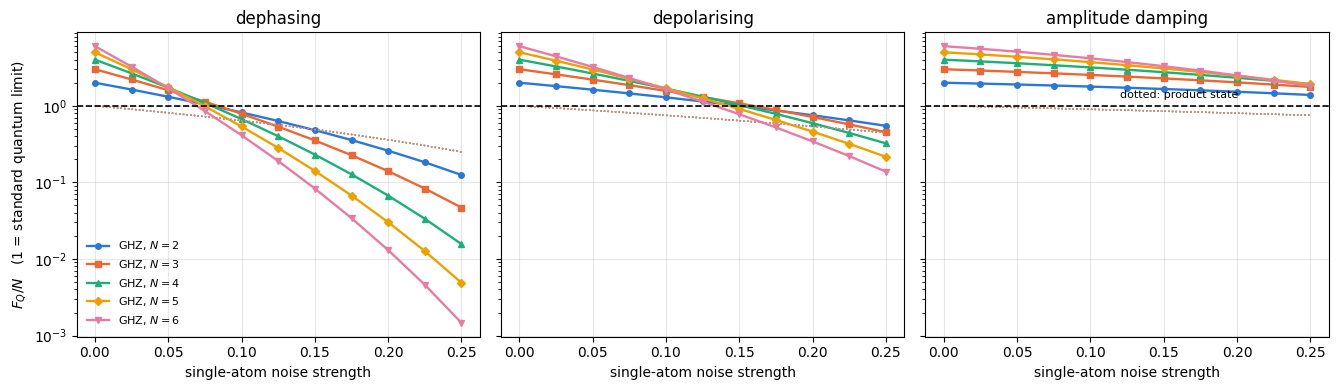

In [16]:
# ==============================================================================
# FIGURE 4: the collapse of the entanglement advantage
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharey=True)
for ax, (name, _) in zip(axes, CHANNELS.items()):
    for i, N in enumerate(N_GRID):
        ax.plot(P_GRID, qfi_tab[name][i] / N, color=PALETTE[i], lw=1.7, marker=MARKERS[i], ms=4,
                label=rf"GHZ, $N={N}$")
        ax.plot(P_GRID, qfi_prod[name][i] / N, color=PALETTE[i], lw=1.0, ls=":")
    ax.axhline(1.0, color="k", lw=1.2, ls="--")
    ax.set_xlabel("single-atom noise strength")
    ax.set_title(name)
    ax.set_yscale("log")
axes[0].set_ylabel(r"$F_Q/N$   (1 = standard quantum limit)")
axes[0].legend(fontsize=8)
axes[2].text(0.12, 1.25, "dotted: product state", fontsize=8)
fig.tight_layout(); plt.show()

The vertical axis is $F_Q/N$: a value of $1$ means "as good as $N$ **noiseless** uncorrelated atoms", and the ideal GHZ
probe starts at $N$. Only one dotted curve is visible in each panel because the product state has $F_Q=N\,f(\text{noise})$
with an $N$-independent $f$, so all five product curves coincide — that is precisely what "the standard quantum limit is a
scaling law, not a state" means.

The figure therefore contains **two** break-even points, and they are not the same number. The dashed line at $1$ is the
crossing with the ideal standard quantum limit, table (a); the crossing with the *dotted* curve — the product state
exposed to the same noise — is the one an experimentalist faces, table (b), and it always sits at a larger noise strength.
For dephasing the two are $N(1-2p)^{2N}=1$ and $N(1-2p)^{2N-2}=1$, the latter being exactly Eq. (17) with $C_1=1-2p$.

* **Dephasing.** Table (a) follows from Eq. (16): $N(1-2p)^{2N}=1$ gives $p=\tfrac12\big(1-N^{-1/(2N)}\big)$, which for
  small $\ln N/N$ expands to $p\simeq\ln N/(4N)$ — the last column shows that approximation running six to eight per cent
  high. Both are **non-monotonic**, peaking at $N=3$ ($0.0845$) simply because $\ln N/N$ does, and falling afterwards
  ($0.0706$ at $N=6$); the asymptotic trend is the decrease. Table (b), $p=\tfrac12\big(1-N^{-1/(2N-2)}\big)$, is
  monotonically decreasing from $0.1464$ at $N=2$ to $0.0820$ at $N=6$ and is the honest statement of when a cat state stops
  paying. Beyond break-even the curves cross *each other*: at $p=0.15$ the $N=6$ probe has $F_Q/N=0.083$ against $0.48$ for
  $N=2$, so a *larger* cat state is *worse*.
* **Depolarising.** The same picture shifted right; against the equally noisy product state the small probes never cross
  inside the plotted range at all.
* **Amplitude damping.** No crossing inside the plotted range for any $N$ tested (both tables report "> 0.25"): at $g=0.25$
  the $N=6$ probe still has $F_Q/N\simeq1.8$. The channel is not unital and drags every atom towards $\vert0\rangle$, which
  costs the coherence only $\sqrt{1-g}$ per atom instead of $(1-2p)$.

The dephasing panel is the only one where the parity measurement extracts all of the plotted $F_Q$; in the other two the
curve is $1/t$ times what parity reaches, and the three-outcome readout of Section 10.4 closes the gap.

In [17]:
# ==============================================================================
# STEP 10: achieved sensitivity from simulated parity records under dephasing
# ==============================================================================
M_NZ, K_NZ = 400, 6000
print(f"Dephasing, contrast C = (1-2p)^N, M = {M_NZ} repetitions, K = {K_NZ} experiments\n")
print(f"{'N':>3s} {'p':>6s} {'C':>9s} {'Delta phi measured':>20s} {'error':>9s} {'1/(N C sqrt M)':>16s} "
      f"{'ratio':>7s} {'SQL 1/sqrt(NM)':>16s} {'gain':>7s}")
key = jax.random.PRNGKey(31415)
for N in (4, 8):
    for p in (0.0, 0.02, 0.05, 0.1):
        C = float((1 - 2 * p) ** N)
        key, sub = jax.random.split(key)
        k = parity_counts(sub, np.pi / (2 * N), float(N), M_NZ, K_NZ, contrast=C)
        s = float(np.std(np.asarray(phi_hat_parity(k, N, M_NZ, contrast=C)), ddof=1))
        pred = 1 / (N * C * np.sqrt(M_NZ))
        sql = 1 / np.sqrt(N * M_NZ)
        print(f"{N:3d} {p:6.2f} {C:9.5f} {s:20.6f} {float(std_of_std(s, K_NZ)):9.6f} {pred:16.6f} "
              f"{s / pred:7.4f} {sql:16.6f} {sql / s:7.3f}")

Dephasing, contrast C = (1-2p)^N, M = 400 repetitions, K = 6000 experiments

  N      p         C   Delta phi measured     error   1/(N C sqrt M)   ratio   SQL 1/sqrt(NM)    gain


  4   0.00   1.00000             0.012418  0.000113         0.012500  0.9934         0.025000   2.013
  4   0.02   0.84935             0.014754  0.000135         0.014717  1.0025         0.025000   1.694
  4   0.05   0.65610             0.019165  0.000175         0.019052  1.0059         0.025000   1.304
  4   0.10   0.40960             0.030884  0.000282         0.030518  1.0120         0.025000   0.809
  8   0.00   1.00000             0.006295  0.000057         0.006250  1.0071         0.017678   2.808
  8   0.02   0.72139             0.008709  0.000080         0.008664  1.0052         0.017678   2.030
  8   0.05   0.43047             0.014439  0.000132         0.014519  0.9945         0.017678   1.224
  8   0.10   0.16777             0.039306  0.000359         0.037253  1.0551         0.017678   0.450


The measured sensitivities follow Eq. (15) to within about one per cent until the contrast collapses (the last row,
$N=8$, $p=0.1$, $C=0.168$, drifts $5.5\%$ high because the estimator starts to clip). The "gain" column is the ratio to the
**noiseless** standard quantum limit at the same $N$ and $M$: it starts at $\sqrt N$ — measured $2.013$ for $N=4$ and
$2.808$ for $N=8$, against $2.000$ and $2.828$ — and falls below $1$ between $p=0.05$ and $p=0.1$ for both sizes. The larger
probe falls faster: at $p=0.05$ the gain is $1.304$ for $N=4$ but only $1.224$ for $N=8$, and at $p=0.1$ it is $0.809$
against $0.450$. Larger cat states are not merely harder to make; once made, they are worth less.

Against an *equally dephased* product state the numbers are milder by the single-atom factor $C_1=1-2p$, since
$\Delta\varphi_{\mathrm{SQL}}=1/(\sqrt N C_1\sqrt M)$: at $N=8$, $p=0.1$ the GHZ probe is worse by $1/(0.450/0.8)=1.78$
rather than by $1/0.450=2.22$. Both statements are true; they answer different questions, and quoting the first one as
"worse than uncorrelated atoms" would compare a noisy probe with an ideal one.

## 12. Losing one atom

Particle loss is the sharpest version of the same statement. Suppose one atom escapes the trap, or one detector fails, during
the interrogation. The experimenter is left with the reduced state of the remaining $N-1$ atoms, and the phase they can
estimate is the one imprinted on *those* atoms, i.e. with generator $J_z^{(N-1)}$.

For the GHZ state, tracing out atom $N-1$ gives

$$\rho_{N-1}=\mathrm{Tr}_{N-1}\vert\mathrm{GHZ}(\varphi)\rangle\langle\mathrm{GHZ}(\varphi)\vert
=\frac12\big(\vert\bar0\rangle\langle\bar0\vert+\vert\bar1\rangle\langle\bar1\vert\big),$$

because the lost atom's state is $\vert0\rangle$ in one branch and $\vert1\rangle$ in the other, and those are orthogonal:
the trace kills the coherence completely. The survivor is a **classical mixture**, diagonal in the eigenbasis of
$J_z^{(N-1)}$. In the SLD formula (2) every pair then has either $\lambda_m=\lambda_n$ (vanishing numerator) or
$\langle m\vert G\vert n\rangle=0$, because a generator diagonal in the computational basis cannot connect two different
basis states. Hence

$$F_Q=0\ \text{ exactly.}$$

A product state loses exactly one atom's worth, $F_Q=N\to N-1$. This is the operational meaning of "the entanglement is not
stored in any subsystem" from
[notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb).

In [18]:
# ==============================================================================
# STEP 11: QFI of the survivors after losing L atoms
# ==============================================================================
print(f"{'N':>4s} {'atoms lost':>11s} {'F_Q GHZ survivors':>19s} {'F_Q product survivors':>22s} "
      f"{'(N-L)^2':>9s} {'N-L':>6s}")
err_loss = 0.0
for N in (4, 6):
    for L in (0, 1, 2):
        keep = list(range(N - L))
        rg = rdm_dm(to_dm(ghz_encoded(N, 0.1)), keep)
        rp = to_dm(collective_pulse(zero_state(N), ry(jnp.pi / 2)))
        for q in range(N):
            rp = apply_gate_dm(rp, rz(0.1), [q])
        rp = rdm_dm(rp, keep)
        G = collective_dense(Z, N - L)
        fg, fp = float(qfi_mixed(rg, G)), float(qfi_mixed(rp, G))
        if L > 0:
            err_loss = max(err_loss, abs(fg))
        print(f"{N:4d} {L:11d} {fg:19.9f} {fp:22.9f} {(N - L) ** 2:9d} {N - L:6d}")
print(f"\nlargest QFI of a GHZ state that has lost at least one atom: {err_loss:.2e}")
assert err_loss < 1e-9

   N  atoms lost   F_Q GHZ survivors  F_Q product survivors   (N-L)^2    N-L
   4           0        16.000000000            4.000000000        16      4


   4           1         0.000000000            3.000000000         9      3
   4           2         0.000000000            2.000000000         4      2
   6           0        36.000000000            6.000000000        36      6


   6           1         0.000000000            5.000000000        25      5


   6           2         0.000000000            4.000000000        16      4

largest QFI of a GHZ state that has lost at least one atom: 0.00e+00


Losing a single atom takes the GHZ probe from $F_Q=N^2$ to $F_Q=0$ — the printed value is exactly zero, because the SLD
formula (2) contains $\vert\langle m\vert G\vert n\rangle\vert^2$ with $G$ diagonal in the eigenbasis of $\rho$, so every
surviving term vanishes identically — while the product state degrades from $N$ to $N-L$ exactly. No noise model is needed
for this; it is the geometry of the state. Any protocol that relies on a large cat state must therefore either detect every
particle or discard the run.

## 13. Frequency estimation: the advantage disappears

### 13.1 The task

A clock does not estimate a phase, it estimates a frequency $\delta=\varphi/T$ at a fixed total measurement time
$T_{\mathrm{tot}}$, which buys $M=T_{\mathrm{tot}}/T$ repetitions. [Notebook 31](./31_ramsey_interferometry.ipynb),
Section 16, did this for uncorrelated atoms:

$$\Delta\delta_{\mathrm{SQL}}=\frac{e^{\gamma T}}{\sqrt{N\,T_{\mathrm{tot}}\,T}},\qquad
T^{\mathrm{SQL}}_{\mathrm{opt}}=\frac{1}{2\gamma},\qquad
\Delta\delta^{\min}_{\mathrm{SQL}}=\sqrt{\frac{2e\gamma}{N\,T_{\mathrm{tot}}}}. \tag{18}$$

### 13.2 The same calculation for GHZ

Combine Eq. (15) with the contrast (14), $C=e^{-N\gamma T}$. The link between the rate $\gamma$ and the channel parameter
used everywhere else is Section 10.1: a single atom dephased for a time $T$ has $p=\tfrac12(1-e^{-\gamma T})$, i.e.
$1-2p=e^{-\gamma T}$, so $\gamma$ is the single-atom transverse decay rate ($T_2=1/\gamma$ in this convention) and $T$
enters the contrast only through it. Then

$$\Delta\delta_{\mathrm{GHZ}}=\frac{\Delta\varphi}{T}=\frac{e^{N\gamma T}}{N\,T\sqrt{M}}
=\frac{e^{N\gamma T}}{N\,T}\sqrt{\frac{T}{T_{\mathrm{tot}}}}
=\frac{e^{N\gamma T}}{N\sqrt{T_{\mathrm{tot}}\,T}}. \tag{19}$$

Minimise over $T$: the $T$-dependence is $e^{N\gamma T}/\sqrt T$, whose logarithm is $N\gamma T-\tfrac12\ln T$, with
derivative $N\gamma-1/(2T)$, so

$$T^{\mathrm{GHZ}}_{\mathrm{opt}}=\frac{1}{2N\gamma}. \tag{20}$$

**The optimal interrogation time is $N$ times shorter.** The entangled probe accumulates phase $N$ times faster, but it also
decoheres $N$ times faster, and the optimum sits where those balance. Substituting (20) into (19):

$$\Delta\delta^{\min}_{\mathrm{GHZ}}=\frac{e^{1/2}}{N\sqrt{T_{\mathrm{tot}}/(2N\gamma)}}
=\frac{\sqrt e\,\sqrt{2N\gamma}}{N\sqrt{T_{\mathrm{tot}}}}
=\sqrt{\frac{2e\gamma}{N\,T_{\mathrm{tot}}}}
\;=\;\Delta\delta^{\min}_{\mathrm{SQL}}. \tag{21}$$

The two are **identical**, including the constant. Under Markovian dephasing with a fixed total measurement time, a
maximally entangled probe used optimally is exactly as good as uncorrelated atoms used optimally — no better, no worse. This
is the central result of Huelga and co-workers (1997). The factor $N$ gained in the phase is returned in full through the
factor $N$ lost in the usable interrogation time, and both final answers scale as $1/\sqrt N$.

**The assumptions this rests on.** (i) The contrast is *exponential* in $T$, $C=e^{-N\gamma T}$, which is what a Markovian
(memoryless) dephasing bath gives. (ii) The atoms dephase **independently**, so the $N$-body coherence decays $N$ times
faster; correlated, common-mode noise gives $N^2$ instead and is worse still
([notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb)). (iii) The dephasing is
*parallel* to the generator ($Z$ noise for a $J_z$ phase). (iv) State preparation and readout are instantaneous, so
$M=T_{\mathrm{tot}}/T$ with no dead time, and $T$ may be chosen freely — in a real clock the dead time is what makes very
short $T$ expensive, and it hurts the GHZ probe more because the GHZ optimum is $N$ times shorter.

The result is not a statement that entanglement is useless. It says that *this* entangled state, against *this* noise model,
at the *asymptotically optimal* operating point, buys nothing. Each assumption above is a door, and all of them have been
opened:

* **Partially entangled probes** buy a constant factor — this is the actual conclusion of Huelga and co-workers, whose
  abstract states that the best resolution comes from "partially entangled preparations with a high degree of symmetry";
  the ultimate constant under Markovian dephasing is fixed by Demkowicz-Dobrzanski, Kolodynski and Guta (2012).
* **Non-Markovian noise.** At times short compared with the bath correlation time the contrast is Gaussian,
  $C=e^{-N(\gamma T)^2}$, and repeating the optimisation above gives $T_{\mathrm{opt}}=1/(2\sqrt N\gamma)$ and
  $\Delta\delta_{\min}\propto N^{-3/4}$ — a genuine, if reduced, quantum advantage (the "Zeno" regime: Matsuzaki, Benjamin
  and Fitzsimons 2011; Chin, Huelga and Plenio 2012). Exercise 8 asks you to reproduce this.
* **Transversal noise.** Dephasing perpendicular to the generator does not commute with the encoding, and the
  $N^{-1/2}$ verdict becomes $N^{-3/4}$ (Chaves and co-workers 2013).
* **Error-corrected sensors**, which remove the noise from the code space while keeping the signal (Kessler, Lovchinsky,
  Sushkov and Lukin 2014).

What dies here is the *quadratic* improvement, under the four assumptions above and no others.

### 13.3 Verification

We scan $T$ for both probes, computing (18) and (19) analytically and simulating clock runs at each $T$. As in notebook 31
the clock is operated at mid-fringe by the conventional quarter-period offset, so that the signal is linear in $\delta$
around $\delta=0$: for the GHZ probe the fringe is $p_+=\tfrac12(1+C\sin(N\delta T))$ and the estimator inverts it.

In [19]:
# ==============================================================================
# STEP 12: clock runs at fixed total time, GHZ vs product, scanning T
# ==============================================================================
GAMMA, T_TOT, K_CL = 1.0, 2000.0, 4000          # gamma = 1 sets the time unit


@partial(jax.jit, static_argnames=("shots", "n_exp"))
def ghz_clock_counts(key, delta, T, contrast, N, shots, n_exp):
    """GHZ clock at mid-fringe: p_+ = (1 + C sin(N delta T))/2.  Returns the +1 counts per run."""
    p = (1 + contrast * jnp.sin(N * delta * T)) / 2
    return jnp.sum(jax.random.bernoulli(key, p, (n_exp, shots)), axis=1)


@partial(jax.jit, static_argnames=("N", "shots", "n_exp"))
def ramsey_clock_counts(key, delta, T, contrast, N, shots, n_exp):
    """Product-state clock at mid-fringe: each atom excited with probability (1 + C sin(delta T))/2."""
    p = (1 + contrast * jnp.sin(delta * T)) / 2
    return jnp.sum(jax.random.bernoulli(key, p, (n_exp, shots, N)), axis=(1, 2))


N_CL = 8
T_GHZ = np.array([0.01, 0.02, 0.0325, 0.05, 0.0625, 0.08, 0.1, 0.15, 0.25, 0.4, 0.6])
T_RAM = np.array([0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 1.0, 1.5, 2.5])
res = {}
key = jax.random.PRNGKey(99)
for tag, Ts in (("GHZ", T_GHZ), ("product", T_RAM)):
    meas, pred = [], []
    for T in Ts:
        M = max(int(T_TOT // T), 1)
        key, sub = jax.random.split(key)
        if tag == "GHZ":
            C = float(np.exp(-N_CL * GAMMA * T))
            k = ghz_clock_counts(sub, 0.0, float(T), C, float(N_CL), M, K_CL)
            d = np.arcsin(np.clip((2 * np.asarray(k, float) / M - 1) / C, -1, 1)) / (N_CL * T)
            pred.append(np.exp(N_CL * GAMMA * T) / (N_CL * np.sqrt(T_TOT * T)))
        else:
            C = float(np.exp(-GAMMA * T))
            k = ramsey_clock_counts(sub, 0.0, float(T), C, N_CL, M, K_CL)
            d = np.arcsin(np.clip((2 * np.asarray(k, float) / (N_CL * M) - 1) / C, -1, 1)) / T
            pred.append(np.exp(GAMMA * T) / np.sqrt(N_CL * T_TOT * T))
        meas.append(float(np.std(d, ddof=1)))
    res[tag] = (Ts, np.array(meas), np.array(pred))

best = np.sqrt(2 * np.e * GAMMA / (N_CL * T_TOT))
print(f"gamma = {GAMMA}, T_tot = {T_TOT}, N = {N_CL}, K = {K_CL} clock runs per point")
print(f"predicted optima:  T_GHZ = 1/(2 N gamma) = {1 / (2 * N_CL * GAMMA):.5f},  "
      f"T_product = 1/(2 gamma) = {1 / (2 * GAMMA):.5f}")
print(f"predicted minimum for BOTH, Eq. (21):  sqrt(2 e gamma/(N T_tot)) = {best:.6f}\n")
for tag in ("GHZ", "product"):
    Ts, meas, pred = res[tag]
    i = int(np.argmin(meas))
    print(f"{tag}:")
    print(f"{'T':>8s} {'M':>7s} {'Delta delta measured':>22s} {'error':>9s} {'analytic':>11s} {'ratio':>7s}")
    for T, m, pr in zip(Ts, meas, pred):
        print(f"{T:8.4f} {int(T_TOT // T):7d} {m:22.6f} {float(std_of_std(m, K_CL)):9.6f} {pr:11.6f} "
              f"{m / pr:7.4f}")
    print(f"  best measured: T = {Ts[i]:.5f}, Delta delta = {meas[i]:.6f}  "
          f"(Eq. (21) minimum: {best:.6f})\n")

# --- CHECKPOINT: the two probes reach the SAME minimum, and it is the one Eq. (21) predicts ------------
m_ghz = res["GHZ"][1].min()
m_prd = res["product"][1].min()
print(f"measured minima:  GHZ {m_ghz:.6f}   product {m_prd:.6f}   ratio {m_ghz / m_prd:.4f}  "
      f"(Eq. (21) says 1.0000)")
print(f"  each against Eq. (21) = {best:.6f}:  {m_ghz / best:.4f} and {m_prd / best:.4f}")
assert abs(m_ghz / m_prd - 1) < 0.05 and abs(m_ghz / best - 1) < 0.05 and abs(m_prd / best - 1) < 0.05

gamma = 1.0, T_tot = 2000.0, N = 8, K = 4000 clock runs per point
predicted optima:  T_GHZ = 1/(2 N gamma) = 0.06250,  T_product = 1/(2 gamma) = 0.50000
predicted minimum for BOTH, Eq. (21):  sqrt(2 e gamma/(N T_tot)) = 0.018433

GHZ:
       T       M   Delta delta measured     error    analytic   ratio
  0.0100  199999               0.030488  0.000341    0.030279  1.0069
  0.0200   99999               0.023085  0.000258    0.023194  0.9953
  0.0325   61538               0.020198  0.000226    0.020108  1.0045
  0.0500   39999               0.018648  0.000209    0.018648  1.0000
  0.0625   32000               0.018691  0.000209    0.018433  1.0140
  0.0800   24999               0.019033  0.000213    0.018741  1.0156
  0.1000   19999               0.019936  0.000223    0.019671  1.0135
  0.1500   13333               0.024322  0.000272    0.023961  1.0151
  0.2500    8000               0.041296  0.000462    0.041306  0.9998
  0.4000    4999               0.116115  0.001298    0.108419  1.

numerical min over T, largest |GHZ/product - 1| over N = 2..32: 3.94e-07;  largest deviation from Eq. (21): 5.09e-07


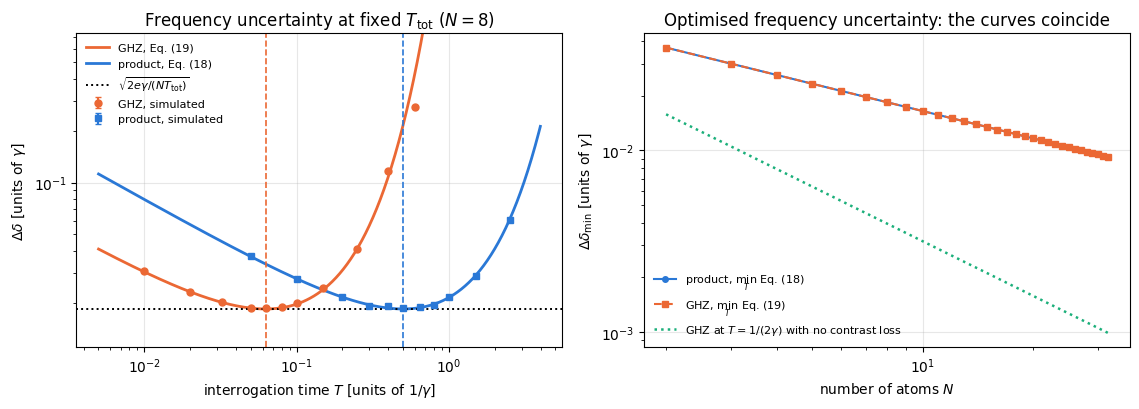

In [20]:
# ==============================================================================
# FIGURE 5: Huelga's result -- two different optimal times, one identical minimum
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

Tf = np.logspace(-2.3, 0.6, 600)
axes[0].plot(Tf, np.exp(N_CL * GAMMA * Tf) / (N_CL * np.sqrt(T_TOT * Tf)), color=PALETTE[1], lw=2.0,
             label=r"GHZ, Eq. (19)")
axes[0].plot(Tf, np.exp(GAMMA * Tf) / np.sqrt(N_CL * T_TOT * Tf), color=PALETTE[0], lw=2.0,
             label=r"product, Eq. (18)")
for tag, col, mk in (("GHZ", PALETTE[1], "o"), ("product", PALETTE[0], "s")):
    Ts, meas, _ = res[tag]
    axes[0].errorbar(Ts, meas, yerr=std_of_std(meas, K_CL), fmt=mk, color=col, ms=5, capsize=2,
                     label=f"{tag}, simulated")
axes[0].axhline(best, color="k", ls=":", lw=1.4, label=r"$\sqrt{2e\gamma/(N T_{\rm tot})}$")
axes[0].axvline(1 / (2 * N_CL * GAMMA), color=PALETTE[1], ls="--", lw=1.2)
axes[0].axvline(1 / (2 * GAMMA), color=PALETTE[0], ls="--", lw=1.2)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"interrogation time $T$ [units of $1/\gamma$]")
axes[0].set_ylabel(r"$\Delta\delta$ [units of $\gamma$]")
axes[0].set_ylim(0.6 * best, 40 * best)
axes[0].set_title(rf"Frequency uncertainty at fixed $T_{{\rm tot}}$ ($N={N_CL}$)")
axes[0].legend(fontsize=8)

NN = np.arange(2, 33)
# Minimise Eqs. (18) and (19) NUMERICALLY over a fine grid of T, separately for each N and each probe:
# nothing here assumes the two answers agree -- that they do is the content of Eq. (21).
# the grid stops at T = 10/gamma: both optima (1/(2 gamma) and 1/(2 N gamma)) sit far inside it, and a
# longer grid would only make exp(N gamma T) overflow at the largest N.
T_fine = np.logspace(-4, 1.0, 4000)
min_prod = np.array([np.min(np.exp(GAMMA * T_fine) / np.sqrt(N * T_TOT * T_fine)) for N in NN])
min_ghz = np.array([np.min(np.exp(N * GAMMA * T_fine) / (N * np.sqrt(T_TOT * T_fine))) for N in NN])
print(f"numerical min over T, largest |GHZ/product - 1| over N = 2..32: "
      f"{np.max(np.abs(min_ghz / min_prod - 1)):.2e};  "
      f"largest deviation from Eq. (21): {np.max(np.abs(min_ghz / np.sqrt(2 * np.e * GAMMA / (NN * T_TOT)) - 1)):.2e}")
assert np.max(np.abs(min_ghz / min_prod - 1)) < 2e-3
axes[1].plot(NN, min_prod, "o-", color=PALETTE[0], ms=4,
             label=r"product, $\min_T$ Eq. (18)")
axes[1].plot(NN, min_ghz, "s--", color=PALETTE[1], ms=4,
             label=r"GHZ, $\min_T$ Eq. (19)")
axes[1].plot(NN, 1 / (NN * np.sqrt(T_TOT * 0.5)), ":", color=PALETTE[2], lw=1.8,
             label=r"GHZ at $T=1/(2\gamma)$ with no contrast loss")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"number of atoms $N$"); axes[1].set_ylabel(r"$\Delta\delta_{\min}$ [units of $\gamma$]")
axes[1].set_title("Optimised frequency uncertainty: the curves coincide")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

**Left.** Two curves with minima a factor $N=8$ apart in $T$ — at $1/(2N\gamma)=0.0625/\gamma$ for the GHZ probe and at
$1/(2\gamma)=0.5/\gamma$ for the product state — that touch the *same* horizontal line
$\sqrt{2e\gamma/(NT_{\mathrm{tot}})}=0.018433\gamma$. The simulated clock runs follow the GHZ curve to better than $1.6\%$
over the whole scan except the two largest GHZ times, and the product curve to better than $2.8\%$ (its worst point,
$T=0.4$, is $2.4$ error bars away — a statistical outlier, not a systematic drift). The measured minima are
$0.018648\gamma$ at $T=0.05$ for the GHZ probe and
$0.018612\gamma$ at $T=0.5$ for the product state: identical within the $1.1\%$ error bars, and both one per cent above
Eq. (21). The GHZ minimum landed on the neighbouring grid point rather than on $T=0.0625$ because the analytic curve
varies by less than $1.7\%$ across the whole stretch $T=0.05\dots0.08$, while the two measured values there differ by
$0.2\%$ — far inside the $1.1\%$ scatter of $4000$ clock runs. The
last GHZ point, $T=0.6$, falls *below* its analytic curve because the contrast there is $e^{-4.8}=0.008$ and the estimator
is clipped — the same saturation seen in notebook 31, Section 13.
Away from its own optimum each probe is much worse than the other: at $T=0.5/\gamma$ the GHZ contrast is $e^{-4}=0.018$,
and at $T=0.0625/\gamma$ the product state is throwing away coherence it has not yet used.

**Right.** The optimised uncertainty against $N$. Each point is a *separate* numerical minimisation of Eq. (18) or Eq. (19)
over a grid of $4000$ interrogation times — the two curves are computed from different formulas with different optima, and
they nevertheless coincide to better than $10^{-6}$ (the printed value is the grid resolution, not a physical difference),
which is Eq. (21) verified rather than assumed. Both fall as $1/\sqrt N$. The
dotted line shows what the GHZ probe *would* achieve if it could keep the product state's interrogation time without paying
the $N$-fold decoherence — the $1/N$ scaling that is lost.

> **Physics insight.** The lesson is not "entanglement does not help", but "a resource must be counted against the noise it
> is exposed to". The GHZ state converts one unit of coherence time into $N$ units of phase; Markovian dephasing charges it
> $N$ units of coherence time for the privilege. The exchange rate is exactly one. Protocols that do win — spin squeezing
> ([notebook 33](./33_spin_squeezing_one_axis_twisting.ipynb)), partially entangled probes, error-corrected sensors —
> all work by making the exchange rate favourable rather than by maximising the phase amplification.

## 14. Scrambling the probe, and estimation from randomised measurements

### 14.1 The setup

Suppose that after the phase has been encoded the probe passes through an uncontrolled, but *known*, unitary $U$ — a
scrambling circuit, an unwanted many-body evolution, a transformation the experimentalist performs on purpose in order to
spread the signal. The state is

$$\vert\Psi\rangle=U\,e^{-i\varphi J_z}\vert\mathrm{GHZ}_N\rangle .$$

Nothing has been lost. Quantum Fisher information is invariant under any $\varphi$-independent unitary (the generator simply
becomes $UJ_zU^\dagger$), so $F_Q=N^2$ still. What *has* changed is where the signal sits: the parity operator in the
original basis is now the wrong observable, and the right one is

$$P'=U\,X^{\otimes N}\,U^\dagger,\qquad \langle\Psi\vert P'\vert\Psi\rangle=\cos(N\varphi)\ \text{ exactly.}$$

### 14.2 Measuring a global observable with local measurements

$P'$ is a dense $2^N\times2^N$ operator. Expanding it in the Pauli basis,

$$P'=\sum_{s\in\{I,X,Y,Z\}^N}\alpha_s\,P_s,\qquad
\alpha_s=\frac{\mathrm{Tr}(P_sP')}{2^N}, \tag{22}$$

with $4^N$ real coefficients obeying $\sum_s\alpha_s^2=\mathrm{Tr}(P'^2)/2^N=1$. For a Haar-random $U$ the weight is spread
over essentially all of them, including the ones of full Pauli weight $N$.

The randomised-measurement (classical-shadow) protocol of
[notebook 24](../ch08_quantum_information_protocols/24_classical_shadows.ipynb) estimates any $\langle P_s\rangle$ from
snapshots in random local Pauli bases: each snapshot draws a basis $b_q\in\{X,Y,Z\}$ per atom, measures, and contributes

$$o_s=\prod_{q\in\mathrm{supp}(P_s)}3\,[\,b_q=s_q\,]\,(-1)^{\mathrm{bit}_q}$$

with $\mathbb E[o_s]=\langle P_s\rangle$. Because the estimator is **linear**, the single-snapshot estimator of
$\langle P'\rangle$ is one contraction,

$$o_{P'}=\sum_s\alpha_s\,o_s=\sum_{s_0\dots s_{N-1}}\alpha_{s_0\dots s_{N-1}}\,v^{(0)}_{s_0}\cdots v^{(N-1)}_{s_{N-1}},$$

where the per-atom vector is $v^{(q)}=\big(1,\ 3\,[b_q{=}X](-1)^{\mathrm{bit}_q},\ 3\,[b_q{=}Y](-1)^{\mathrm{bit}_q},\
3\,[b_q{=}Z](-1)^{\mathrm{bit}_q}\big)$. That is an `einsum` of a rank-$N$ tensor with $N$ vectors — for $N=3$, the string
`"a,b,c,abc->"` — and `vmap` runs it over all snapshots.

### 14.3 The cost

A snapshot contributes to $o_s$ only if its random bases match $s$ on the whole support of $s$, which happens with
probability $3^{-w}$, and then contributes $\pm3^w$. Hence $\mathbb E[o_s^2]=3^w$ exactly, for every state and every
weight-$w$ string. For the sum, the cross terms $\mathbb E[o_so_{s'}]$ with $s\ne s'$ have random signs under a Haar
$U$ and average away, so

$$\mathrm{Var}(o_{P'})\ \simeq\ \sum_s\alpha_s^2\,3^{w(s)}-\langle P'\rangle^2 . \tag{23}$$

The worst case is $3^N$, reached if all the weight sat on a single full-weight string. That is **not** what a Haar-random
$U$ does. A Haar-scrambled traceless operator spreads its weight uniformly over the $4^N-1$ non-identity strings,
$\mathbb E_U[\alpha_s^2]=1/(4^N-1)$, and the number of strings of weight $w$ is $\binom Nw3^w$, so

$$\mathbb E_U\Big[\sum_s\alpha_s^2 3^{w(s)}\Big]=\frac{1}{4^N-1}\sum_{w=1}^{N}\binom Nw3^w\cdot3^w
=\frac{\sum_{w=0}^{N}\binom Nw9^w-1}{4^N-1}=\frac{10^N-1}{4^N-1}\ \xrightarrow[\ N\gg1\ ]{}\ \Big(\frac52\Big)^{\!N}. \tag{24}$$

The geometric mean of the per-atom factor is $10/4=2.5$, not $3$: most of the Pauli weight sits at $w\simeq\tfrac34N$, not
at $w=N$, and the $3^w$ penalty is paid on that typical weight. (The sum $\sum_s3^{w(s)}=(1+3\cdot3)^N=10^N$ is the same
combinatorial identity that fixes the cost of shadow tomography in
[notebook 24](../ch08_quantum_information_protocols/24_classical_shadows.ipynb).)

Reaching a target error $\sigma$ therefore needs $n_{\mathrm{shadows}}\simeq(5/2)^N/\sigma^2$ snapshots. **Heisenberg
scaling in $N$ is recovered, but only at an exponentially growing measurement budget.** We measure both statements below.

### 14.4 Implementation

In [21]:
# ==============================================================================
# STEP 13: Pauli decomposition of the scrambled parity, and the shadow estimator
# ==============================================================================
SIGMAS = jnp.stack([I2, X, Y, Z])          # index order I, X, Y, Z -- matches the shadow basis codes +1


def pauli_decomposition(P_mat, N):
    """All 4^N Pauli coefficients of an operator, Eq. (22), as a rank-N tensor alpha[s_0,...,s_{N-1}].

    MATH   alpha_s = Tr(P_s P')/2^N  with  P_s = sigma_{s_0} (x) ... (x) sigma_{s_{N-1}}.
           Writing P' as a rank-2N tensor P'[a_0..a_{N-1}; b_0..b_{N-1}],
               Tr(P_s P') = sum_{a,b} prod_q sigma_{s_q}[b_q, a_q] P'[a..; b..]
           which is ONE einsum with N copies of the (4,2,2) array SIGMAS.
    EINSUM TRANSLATION  N=2:  "iBA,jDC,ACBD->ij"   (A,C = ket axes, B,D = bra axes, i,j = Pauli labels)
    COST   O(4^N 2^N) with the optimised contraction path; used for N <= 5 here.
    """
    Pt = jnp.asarray(P_mat, dtype=CDTYPE).reshape((2,) * (2 * N))
    a = [_LETTERS[q] for q in range(N)]                      # ket axes of P'
    b = [_LETTERS[N + q] for q in range(N)]                  # bra axes of P'
    i = [_LETTERS[2 * N + q] for q in range(N)]              # Pauli label of each atom
    sub = ",".join(f"{i[q]}{b[q]}{a[q]}" for q in range(N)) + \
          f",{''.join(a)}{''.join(b)}->{''.join(i)}"
    return jnp.real(jnp.einsum(sub, *([SIGMAS] * N), Pt)) / 2 ** N


def shadow_estimates(alpha, bases, bits):
    """Single-snapshot estimates of <P'> for every snapshot of a Pauli-shadow data set.

    MATH   o = sum_s alpha_s prod_q v^{(q)}_{s_q},
           v^{(q)} = (1, 3[b_q=X](-1)^{bit}, 3[b_q=Y](-1)^{bit}, 3[b_q=Z](-1)^{bit}).
    IMPLEMENTATION  the product over q of a per-atom 4-vector contracted with the rank-N tensor alpha:
           one einsum "a,b,...,ab...->" per snapshot, vmapped over snapshots.
    RETURNS an array of shape (n_shadows,); its mean estimates <P'>, its std/sqrt(n) the error.
    """
    N = alpha.ndim
    sub = ",".join(_LETTERS[q] for q in range(N)) + "," + _LETTERS[:N] + "->"

    def one(b_row, s_row):
        sgn = 1 - 2 * s_row                                   # (-1)^{bit} for each atom
        v = jnp.stack([jnp.ones(N), 3.0 * (b_row == 0) * sgn,
                       3.0 * (b_row == 1) * sgn, 3.0 * (b_row == 2) * sgn], axis=1)   # (N,4)
        return jnp.einsum(sub, *[v[q] for q in range(N)], alpha)

    return jax.vmap(one)(bases, bits)


shadow_estimates_jit = jax.jit(shadow_estimates)

# --- CHECKPOINT: the decomposition reconstructs the operator, and <P'> = cos(N phi) -------------------
import itertools

N_D = 3
U_D = haar_unitary(jax.random.PRNGKey(4), 2 ** N_D)
P_D = jnp.asarray(X, dtype=CDTYPE)
for _ in range(N_D - 1):
    P_D = jnp.kron(P_D, X)
Pp_D = U_D @ P_D @ U_D.conj().T
alpha_D = pauli_decomposition(Pp_D, N_D)

rec = np.zeros((2 ** N_D, 2 ** N_D), complex)
for s in itertools.product(range(4), repeat=N_D):
    M_ = np.eye(1)
    for q in s:
        M_ = np.kron(M_, np.asarray(SIGMAS[q]))
    rec += float(alpha_D[s]) * M_
print(f"N = {N_D}:  4^N = {4 ** N_D} Pauli coefficients")
print(f"  |P' - sum_s alpha_s P_s|_max      = {np.abs(rec - np.asarray(Pp_D)).max():.2e}")
print(f"  sum_s alpha_s^2                   = {float(jnp.sum(alpha_D ** 2)):.12f}   (must be 1)")
print(f"  weight of full-weight (N-body) terms = "
      f"{float(jnp.sum(alpha_D[1:, 1:, 1:] ** 2)):.4f}  of the total")
for phi in (0.1, 0.3):
    psi_s = apply_gate(ghz_encoded(N_D, phi), U_D, list(range(N_D)))
    exact = float(jnp.real(jnp.vdot(psi_s.reshape(-1), Pp_D @ psi_s.reshape(-1))))
    print(f"  phi = {phi}:  <P'> on the scrambled state = {exact:.12f},  cos(N phi) = {np.cos(N_D * phi):.12f}")
    assert abs(exact - np.cos(N_D * phi)) < 1e-9
assert np.abs(rec - np.asarray(Pp_D)).max() < 1e-9 and abs(float(jnp.sum(alpha_D ** 2)) - 1) < 1e-9

N = 3:  4^N = 64 Pauli coefficients
  |P' - sum_s alpha_s P_s|_max      = 1.24e-16
  sum_s alpha_s^2                   = 1.000000000000   (must be 1)
  weight of full-weight (N-body) terms = 0.5970  of the total


  phi = 0.1:  <P'> on the scrambled state = 0.955336489126,  cos(N phi) = 0.955336489126
  phi = 0.3:  <P'> on the scrambled state = 0.621609968271,  cos(N phi) = 0.621609968271


The decomposition is exact, the coefficients are normalised, and the scrambled expectation value of $P'$ reproduces
$\cos(N\varphi)$ to machine precision: scrambling moves the signal, it does not destroy it.

In [22]:
# ==============================================================================
# STEP 14: phase estimation from randomised measurements after scrambling
# ==============================================================================
N_SHAD = (2, 3, 4, 5)
N0_SHAD = 1500                                   # budget n_shadows = N0 * 3^N
rows = []
for N in N_SHAD:
    phi_true = np.pi / (2 * N)                   # mid-fringe of the GHZ fringe
    U = haar_unitary(jax.random.PRNGKey(200 + N), 2 ** N)
    P_ = jnp.asarray(X, dtype=CDTYPE)
    for _ in range(N - 1):
        P_ = jnp.kron(P_, X)
    Pp = U @ P_ @ U.conj().T
    alpha = pauli_decomposition(Pp, N)
    psi_s = apply_gate(ghz_encoded(N, phi_true), U, list(range(N)))

    n_sh = N0_SHAD * 3 ** N
    t0 = time.time()
    bases, bits = collect_pauli_shadows(jax.random.PRNGKey(300 + N), psi_s, n_sh)
    est = shadow_estimates_jit(alpha, bases, bits)
    est = np.asarray(jax.block_until_ready(est))
    t_sh = time.time() - t0

    mean, var = est.mean(), est.var(ddof=1)
    se = np.sqrt(var / n_sh)
    phi_hat = np.arccos(np.clip(mean, -1, 1)) / N
    sigma_phi = se / (N * abs(np.sin(N * phi_true)))          # mid-fringe: |sin(N phi)| = 1
    rows.append((N, n_sh, var, mean, se, phi_true, phi_hat, sigma_phi, t_sh))

def haar_variance(N):
    """Haar-averaged single-snapshot variance of a scrambled full-weight Pauli, Eq. (24)."""
    return (10.0 ** N - 1) / (4.0 ** N - 1)


print(f"budget n_shadows = {N0_SHAD} * 3^N, operating at N phi = pi/2\n")
print(f"{'N':>3s} {'n_shadows':>10s} {'Var(1 snapshot)':>16s} {'Eq.(24)':>9s} {'ratio':>7s} {'3^N':>6s} "
      f"{'Var/3^N':>8s} {'<P> estimate':>13s} {'exact':>8s} {'sigma_phi':>11s} {'sigma_phi * N':>14s} "
      f"{'time [s]':>9s}")
for (N, n_sh, var, mean, se, pt, ph, sp, t_sh) in rows:
    print(f"{N:3d} {n_sh:10d} {var:16.3f} {haar_variance(N):9.3f} {var / haar_variance(N):7.3f} "
          f"{3 ** N:6d} {var / 3 ** N:8.3f} {mean:13.5f} {0.0:8.5f} "
          f"{sp:11.6f} {sp * N:14.6f} {t_sh:9.2f}")

print(f"\n{'N':>3s} {'phi_true':>10s} {'phi_hat':>10s} {'|error|':>10s} {'sigma_phi':>11s} "
      f"{'|error|/sigma':>14s}")
for (N, n_sh, var, mean, se, pt, ph, sp, t_sh) in rows:
    print(f"{N:3d} {pt:10.6f} {ph:10.6f} {abs(ph - pt):10.6f} {sp:11.6f} {abs(ph - pt) / sp:14.3f}")

print(f"\nEquivalent DIRECT parity measurements (no scrambling) for the same sigma_phi:")
print(f"{'N':>3s} {'n_shadows used':>15s} {'M direct = 1/(N sigma)^2':>26s} {'overhead':>10s} "
      f"{'Eq.(24)':>9s} {'3^N/2':>8s}")
for (N, n_sh, var, mean, se, pt, ph, sp, t_sh) in rows:
    M_dir = 1 / (N * sp) ** 2
    print(f"{N:3d} {n_sh:15d} {M_dir:26.1f} {n_sh / M_dir:10.1f} {haar_variance(N):9.1f} {3 ** N / 2:8.1f}")

print(f"\nN * sigma_phi at a budget n = n0 * 2.5^N would be flat; at n0 * 3^N it falls like (5/6)^(N/2):")
print(f"{'N':>3s} {'N sigma (measured)':>20s} {'prediction sqrt(Eq.(24)/n)':>28s} {'ratio':>7s}")
for (N, n_sh, var, mean, se, pt, ph, sp, t_sh) in rows:
    pred_ns = np.sqrt(haar_variance(N) / n_sh)
    print(f"{N:3d} {sp * N:20.6f} {pred_ns:28.6f} {sp * N / pred_ns:7.3f}")

budget n_shadows = 1500 * 3^N, operating at N phi = pi/2

  N  n_shadows  Var(1 snapshot)   Eq.(24)   ratio    3^N  Var/3^N  <P> estimate    exact   sigma_phi  sigma_phi * N  time [s]
  2      13500            8.547     6.600   1.295      9    0.950       0.06907  0.00000    0.012581       0.025162      1.69
  3      40500           14.762    15.857   0.931     27    0.547       0.00910  0.00000    0.006364       0.019092      1.77
  4     121500           41.051    39.212   1.047     81    0.507      -0.02703  0.00000    0.004595       0.018381      2.13
  5     364500           97.635    97.751   0.999    243    0.402      -0.03210  0.00000    0.003273       0.016366      2.93

  N   phi_true    phi_hat    |error|   sigma_phi  |error|/sigma
  2   0.785398   0.750833   0.034565    0.012581          2.747
  3   0.523599   0.520566   0.003033    0.006364          0.477
  4   0.392699   0.399458   0.006759    0.004595          1.471
  5   0.314159   0.320581   0.006421    0.003273       

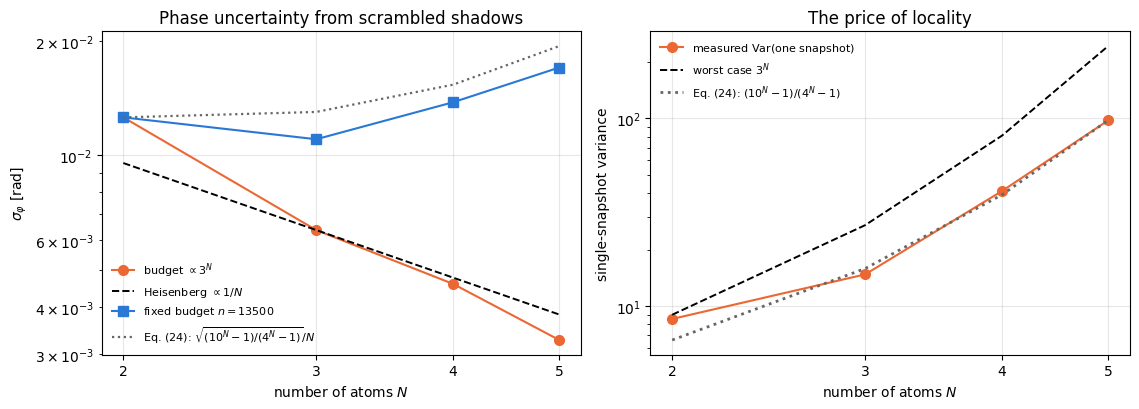

In [23]:
# ==============================================================================
# FIGURE 6: Heisenberg scaling from randomised measurements, and what it costs
# ==============================================================================
Ns = np.array([r[0] for r in rows], float)
sig = np.array([r[7] for r in rows])
varr = np.array([r[2] for r in rows])
n_used = np.array([r[1] for r in rows], float)
# sigma ~ 1/sqrt(n_shadows), so the same data say what a common budget would have given
sig_fixed = sig * np.sqrt(n_used / n_used.min())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].plot(Ns, sig, "o-", color=PALETTE[1], ms=7, label=r"budget $\propto 3^N$")
axes[0].plot(Ns, sig[1] * Ns[1] / Ns, "--", color="k", lw=1.4, label=r"Heisenberg $\propto1/N$")
axes[0].plot(Ns, sig_fixed, "s-", color=PALETTE[0], ms=7,
             label=rf"fixed budget $n={int(n_used.min())}$")
hv = (10.0 ** Ns - 1) / (4.0 ** Ns - 1)                     # Eq. (24)
axes[0].plot(Ns, sig_fixed[0] * np.sqrt(hv / hv[0]) * Ns[0] / Ns, ":", color="0.4", lw=1.6,
             label=r"Eq. (24): $\sqrt{(10^N-1)/(4^N-1)}/N$")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xticks(Ns); axes[0].set_xticklabels([f"{int(n)}" for n in Ns])
axes[0].set_xlabel(r"number of atoms $N$"); axes[0].set_ylabel(r"$\sigma_\varphi$ [rad]")
axes[0].set_title("Phase uncertainty from scrambled shadows")
axes[0].legend(fontsize=8)

axes[1].plot(Ns, varr, "o-", color=PALETTE[1], ms=7, label=r"measured $\mathrm{Var}$(one snapshot)")
axes[1].plot(Ns, 3.0 ** Ns, "--", color="k", lw=1.4, label=r"worst case $3^N$")
axes[1].plot(Ns, hv, ":", color="0.4", lw=2.0, label=r"Eq. (24): $(10^N-1)/(4^N-1)$")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xticks(Ns); axes[1].set_xticklabels([f"{int(n)}" for n in Ns])
axes[1].set_xlabel(r"number of atoms $N$"); axes[1].set_ylabel("single-snapshot variance")
axes[1].set_title("The price of locality")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Both halves of Section 14.3 are visible in the printed table and in the figure.

* **Right panel.** The measured single-snapshot variance grows from $8.5$ at $N=2$ to $97.6$ at $N=5$ and tracks Eq. (24),
  $(10^N-1)/(4^N-1)=6.6$, $15.9$, $39.2$, $97.8$, to within the scatter of a single draw of $U$ — the ratio in the table
  reads $1.29$, $0.93$, $1.05$, $1.00$. It is visibly *below* $3^N$, and the measured ratio $\mathrm{Var}/3^N$ does not
  settle: it falls from $0.95$ to $0.40$, i.e. by a factor close to $2.5/3=0.833$ per atom. The measured growth from one $N$
  to the next is $1.7$, $2.8$, $2.4$ — consistent with the geometric factor $5/2$ of Eq. (24), not with $3$.
* **Left panel.** With a budget $n_{\mathrm{shadows}}=1500\cdot3^N$, the measured $\sigma_\varphi$ follows the $1/N$ line
  and in fact beats it slightly: $N\sigma_\varphi$ reads $0.0252$, $0.0191$, $0.0184$, $0.0164$ for $N=2,3,4,5$, a steady
  decrease rather than a plateau. That is exactly what Eq. (24) predicts. Since
  $N\sigma_\varphi=\sqrt{\mathrm{Var}/n_{\mathrm{shadows}}}$, a budget $\propto3^N$ against a variance $\propto(5/2)^N$
  gives $N\sigma_\varphi\propto(5/6)^{N/2}=0.913^N$ — the last printed table compares the two, and the ratio is $0.96$,
  $1.02$, $1.00$ for $N=3,4,5$ (and $1.14$ at $N=2$, where one Haar draw fluctuates most and Eq. (24) is an average over
  $U$). Heisenberg scaling survives the scrambling; the budget that makes $N\sigma_\varphi$ *exactly* flat is
  $\propto(5/2)^N$, and a $3^N$ budget over-pays.
* At a **fixed** budget (the same data rescaled by $\sqrt{n/n_{\min}}$, which is exact because $\sigma\propto n^{-1/2}$)
  the curve turns around and rises, following the $\sqrt{(10^N-1)/(4^N-1)}/N$ reference: the exponential growth of the
  snapshot variance overwhelms the $1/N$ gain.
* The last-but-one printed table makes the overhead concrete: reaching the same $\sigma_\varphi$ with a *direct* parity
  measurement on the unscrambled state needs $M=1/(N\sigma_\varphi)^2$ repetitions, and the ratio of the two budgets is
  $8.5$, $14.8$, $41.1$ and $97.6$ for $N=2,3,4,5$ — the single-snapshot variance itself, as it must be. Direct parity
  needs a few thousand shots at every $N$; the scrambled protocol needs a hundred times more at $N=5$, and the factor keeps
  multiplying by $5/2$.
* The table of estimates is a reminder that a $1\sigma$ error bar is not a guarantee: at $N=2$ the estimate misses by
  $2.7\sigma$. With four independent points one deviation that large is a $2$–$3\%$ event, and the $N=2$ point also has the
  largest nonlinearity in the $\arccos$ inversion, since $\vert\langle P'\rangle\vert=0.069$ is the furthest from
  mid-fringe.

> **Numerical practice.** "The protocol achieves Heisenberg scaling" and "the protocol achieves Heisenberg scaling at a
> fixed measurement budget" are different claims, and only the first one is true here. Whenever a scaling plot is produced
> with a per-point budget that itself depends on the abscissa, say so and plot the fixed-budget version next to it — and
> check that the budget you chose is the one the physics asks for. Writing $3^N$ where the variance is $(5/2)^N$ costs
> nothing in correctness but hides a factor $(6/5)^N$, which at $N=20$ is $38$.

The $(5/2)^N$ is a statement about **local random Pauli bases**, not about the state or about randomised measurements in
general. Global Clifford shadows have a variance controlled by $\mathrm{Tr}(P'^2)=2^N$ instead
([notebook 24](../ch08_quantum_information_protocols/24_classical_shadows.ipynb)), still exponential but with a smaller
base; and since $U$ is assumed *known*, the cheapest route of all is to apply $U^\dagger$ and measure the ordinary parity,
which costs $O(1)$ snapshots at every $N$. The exponential price is what one pays for refusing to use that knowledge in the
measurement itself.

Scrambling is taken further later in this chapter: [notebook 35](./35_oat_plus_haar_scrambling.ipynb) pushes squeezed
probes through Haar unitaries and brick-wall circuits and computes the Haar average of the collective quantum Fisher
information, and [notebook 38](./38_scramblers_and_qfi.ipynb) measures *how fast* analog and digital scramblers lock the
phase away into the global state.

## 15. Performance and cost

The three cost models used in this notebook, measured rather than quoted.

In [24]:
# ==============================================================================
# STEP 15: timings of the three routes
# ==============================================================================
def timeit_jax(fn, *args, repeats=3):
    """(compile+first call, best of `repeats` subsequent calls) in seconds, with block_until_ready."""
    t0 = time.time(); jax.block_until_ready(fn(*args)); t_first = time.time() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.time(); jax.block_until_ready(fn(*args)); best = min(best, time.time() - t0)
    return t_first, best


print(f"{'task':>42s} {'N':>3s} {'compile [s]':>12s} {'run [s]':>10s} {'memory model':>16s}")
for N in (4, 6):
    c, r = timeit_jax(lambda: parity_counts(jax.random.PRNGKey(0), 0.1, float(N), 400, 8000))
    print(f"{'Bernoulli parity, K=8000 x M=400':>42s} {N:3d} {c:12.3f} {r:10.4f} {'O(K M)':>16s}")
    c, r = timeit_jax(lambda: parity_record_engine(jax.random.PRNGKey(0), 0.1, N, 20000))
    print(f"{'engine X-basis records, 20000 shots':>42s} {N:3d} {c:12.3f} {r:10.4f} {'O(shots 2^N)':>16s}")
    c, r = timeit_jax(lambda: qfi_mixed(dm_matrix(noisy_encoded_dm(N, 0.1, kraus_dephasing(0.05))),
                                        collective_dense(Z, N)))
    print(f"{'density tensor + SLD quantum Fisher info':>42s} {N:3d} {c:12.3f} {r:10.4f} {'O(4^N)':>16s}")

                                      task   N  compile [s]    run [s]     memory model
          Bernoulli parity, K=8000 x M=400   4        0.024     0.0256           O(K M)


       engine X-basis records, 20000 shots   4        0.191     0.0022     O(shots 2^N)
  density tensor + SLD quantum Fisher info   4        0.011     0.0096           O(4^N)
          Bernoulli parity, K=8000 x M=400   6        0.023     0.0252           O(K M)


       engine X-basis records, 20000 shots   6        0.267     0.0085     O(shots 2^N)
  density tensor + SLD quantum Fisher info   6        0.051     0.0222           O(4^N)


Three different scalings sit in one table. The Bernoulli parity sampler is independent of $N$ altogether — the atom number
enters only through $\cos(N\varphi)$ — which is why the sweeps of Sections 8 and 11 could afford $K=8000$ experiments per
point. The engine's $X$-basis sampler costs $O(\text{shots}\cdot2^N)$, so the model predicts a factor $4$ between $N=4$ and
$N=6$. That ratio is the least reproducible number in the table — separate builds of this notebook returned $2.8$ and
$4.9$ — because at these sizes the $2^N$ work does not yet dominate the fixed per-call overhead, which is the usual shape
of a small benchmark. The density-tensor route costs $O(4^N)$ and sets the size limit of
Sections 10-12: at $N=6$ the density tensor already holds $4^6=4096$ complex numbers and the symmetric-logarithmic-derivative
step diagonalises a $64\times64$ matrix, while $N=10$ would need $10^6$ numbers and a $1024\times1024$ eigendecomposition for
every point of a two-dimensional sweep.

The absolute numbers depend on how busy the machine is (these were measured with several other builds running), so read the
*ratios* and the trends, not the seconds. Compile times exceed run times throughout, which is the usual situation for small
jitted programs and the reason every timing here separates the two.

## 16. Key takeaways

* **The gain is exactly $N$ in Fisher information.** $\vert\mathrm{GHZ}_N\rangle$ puts all the weight on the two extreme
  eigenvalues of $J_z$, so $F_Q=4\mathrm{Var}(J_z)=N^2$ against $N$ for a coherent spin state — reproduced to
  $1.4\cdot10^{-14}$ for $N=2\dots10$, together with the $N$-fold relative phase.
* **Only a global observable sees it.** Every single-atom expectation value of the encoded GHZ probe is zero at every phase
  (the printed maximum is exactly $0$). The parity $X^{\otimes N}$ gives $\langle P\rangle=\cos(N\varphi)$; the raw $N$-bit record is
  uniform inside each parity class, so the parity is a sufficient statistic and the record collapses to one bit.
* **Parity is optimal for the ideal probe.** Its classical Fisher information is $N^2$ at every phase strictly inside a
  fringe, equal to $F_Q$, and error propagation gives $\Delta\varphi=1/N$ per repetition. At the fringe extrema the value
  $N^2$ is only a limit and the Cramer-Rao regularity fails; with contrast $C<1$ the information there is exactly zero.
  Running the preparation circuit backwards and measuring one atom is an exactly equivalent readout,
  $p=\sin^2(N\varphi/2)$ — equivalent for the *ideal* probe.
* **Measured Heisenberg scaling.** Sweeping $N=2\dots16$ with $M=400$ and $K=8000$ experiments per point, the measured
  $\Delta\varphi$ followed a power law with fitted exponent $-1.0031$, against $-0.4958$ for the Ramsey protocol run on the
  same atoms and the same repetitions; every point sat within about one per cent of its own bound, and the measured gain at
  $N=16$ was $4.045$ against $\sqrt{16}=4$.
* **Range for resolution.** $\cos(N\varphi)$ has $N$ maxima per $2\pi$, and the likelihood of a generic record has $2N$;
  the unambiguous window shrinks from $\pi$ to $\pi/N$, exactly the factor gained. Two phases differing by $2\pi/N$ produce
  statistically identical records.
* **Fragility is exponential in $N$.** Contrasts $(1-2p)^N$, $\lambda^N$, $(1-g)^{N/2}$, all verified against exact Kraus
  evolution to $4\cdot10^{-16}$. All three channels leave the state diagonal apart from the single coherence
  $\rho_{\bar0\bar1}$, which gives the closed form $F_Q=N^2C^2/t$ with $t=\rho_{\bar0\bar0}+\rho_{\bar1\bar1}$, Eqs. (16a)
  and (16b), reproduced by the SLD formula to machine precision. Dephasing has $t=1$, so $F_Q=N^2(1-2p)^{2N}$ and parity
  saturates it; depolarising and damping have $t<1$, parity loses the factor $1/t$ (measured $1.77$ and $1.42$ at $p=0.2$),
  and the readout that recovers it is the decoding circuit with *all* $N$ atoms read out, independent of the noise.
  Break-even against an equally noisy product state requires $C_1^{N-1}>1/\sqrt N$, i.e. $p=\tfrac12(1-N^{-1/(2N-2)})$ for
  dephasing; against the *ideal* standard quantum limit the crossing is the tighter $p=\tfrac12(1-N^{-1/(2N)})$. Both are
  printed in Section 11. At $N=8$ and a per-atom dephasing of $10\%$ the GHZ probe is $2.2$ times worse than $N$ noiseless
  atoms and $1.8$ times worse than $N$ equally dephased ones.
* **Losing one atom destroys everything.** $F_Q=N^2\to0$ exactly (the printed value is $0$), because the reduced state of
  the survivors is a classical mixture diagonal in the generator's eigenbasis. A product state degrades from $N$ to $N-1$.
* **No asymptotic gain for frequency estimation under Markovian dephasing.** The optimal interrogation time becomes
  $T_{\mathrm{opt}}=1/(2N\gamma)$, and the resulting $\Delta\delta_{\min}=\sqrt{2e\gamma/(NT_{\mathrm{tot}})}$ is *identical*
  to the product-state result, constant included — derived here and reproduced by simulated clock runs, which gave
  $0.018648\gamma$ (GHZ) and $0.018612\gamma$ (product) against the predicted $0.018433\gamma$. The quadratic advantage
  survives only at fixed interrogation time, which is not the resource a clock is given.
* **Scrambling hides the signal without deleting it.** $F_Q$ is invariant under a $\varphi$-independent unitary and
  $\langle UPU^\dagger\rangle=\cos(N\varphi)$ exactly. Randomised local measurements recover it through the $4^N$-term Pauli
  decomposition, with a single-snapshot variance measured at $8.5$, $14.8$, $41.1$, $97.6$ for $N=2\dots5$ against the
  Haar prediction $(10^N-1)/(4^N-1)=6.6$, $15.9$, $39.2$, $97.8$ of Eq. (24) — the cost grows like $(5/2)^N$, not $3^N$,
  because the Pauli weight of a scrambled operator is binomial with mean $3N/4$ rather than concentrated at $N$. At a
  budget $\propto3^N$ the measured $N\sigma_\varphi$ drifts down from $0.025$ to $0.016$ (slightly better than Heisenberg,
  because the budget over-pays); a budget $\propto(5/2)^N$ is the one that makes it flat; at a fixed budget the curve
  turns around and rises. Distinguishing those statements is the main methodological point of Section 14.

## 17. Exercises

1. ★ **Other parities.** Measure $\langle X^{\otimes k}\otimes\mathbb 1^{\otimes(N-k)}\rangle$ on the encoded GHZ probe for
   $k<N$. Predict the result before running, and explain what it implies for an experiment in which $N-k$ detectors fail.
2. ★ **Where does the maximum of $F_Q$ come from?** Verify numerically that among all states of $N$ qubits the maximum of
   $4\mathrm{Var}(J_z)$ is $N^2$, by evaluating $F_Q$ for Dicke states $\vert D_N^k\rangle$, W states, random states and GHZ
   for $N=6$, and explain the ordering you find.
3. ★★ **Partially entangled probes (extend the code).** Replace the GHZ state by
   $\cos\theta\vert\bar0\rangle+\sin\theta\vert\bar1\rangle$ and, more interestingly, by a superposition of the two extreme
   Dicke states with a variable number of atoms participating. For dephasing at a fixed $\gamma T$, find numerically the
   probe that minimises $\Delta\varphi$, and compare with both the GHZ and the product state.
4. ★★ **Optimal measurement under depolarising noise.** Section 10.4 found $F_Q>N^2C^2$: parity is not optimal. Using the
   symmetric-logarithmic-derivative machinery of [notebook 30](./30_qfi_from_the_sld_prepare_encode_estimate.ipynb), build
   the SLD eigenbasis for $N=3$, $p=0.1$, simulate measurements in it, and check that the classical Fisher information of
   the simulated outcomes reaches $F_Q$.
5. ★★ **Adaptive two-stage estimation (physics).** Implement the hierarchy of Section 9: stage one uses uncorrelated atoms
   to localise $\varphi$ inside a window of width $\pi/N$, stage two uses the GHZ probe. Split the total number of
   repetitions between the stages, measure the RMS error over many runs, and find the split that minimises it.
6. ★★ **Atom loss with a known rate (extend the code).** Let each atom be lost independently with probability $\eta$ during
   the interrogation, and let the experimenter know which atoms survived. Compute the average $F_Q$ over loss patterns for
   $N=4,5,6$ and compare with $(1-\eta)^NN^2$. Is discarding lossy runs better than using them?
7. ★★★ **Scrambling with a shallow circuit.** Replace the Haar-random $U$ of Section 14 by a brick-wall circuit of depth
   $d$ (the engine's `brickwall`). Measure how the Pauli weight distribution of $P'$, and hence the single-snapshot
   variance, grows with $d$. At which depth does the asymptotic $(5/2)^N$ cost of Eq. (24) set in? (Expect the Pauli
   weight distribution to converge to the binomial of mean $3N/4$; a shallow circuit keeps $P'$ local and cheap.)
8. ★★★ **The Huelga bound for non-Markovian noise (physics).** Replace the exponential contrast $e^{-N\gamma T}$ by a
   Gaussian one, $e^{-N(\gamma T)^2}$ (the short-time behaviour of many realistic baths). Redo the optimisation of
   Section 13 and show that the GHZ probe then retains a genuine $N^{-3/4}$ scaling. Verify numerically, and explain which
   step of the Markovian argument fails.

## 18. References

* J. J. Bollinger, W. M. Itano, D. J. Wineland and D. J. Heinzen, *Optimal frequency measurements with maximally correlated
  states*, Phys. Rev. A **54**, R4649 (1996) — the protocol of Sections 4–6.
* D. Leibfried, M. D. Barrett, T. Schaetz, J. Britton, J. Chiaverini, W. M. Itano, J. D. Jost, C. Langer and
  D. J. Wineland, *Toward Heisenberg-limited spectroscopy with multiparticle entangled states*, Science **304**, 1476 (2004)
  — the three-ion realisation.
* S. F. Huelga, C. Macchiavello, T. Pellizzari, A. K. Ekert, M. B. Plenio and J. I. Cirac, *Improvement of frequency
  standards with quantum entanglement*, Phys. Rev. Lett. **79**, 3865 (1997) — Section 13.
* R. Demkowicz-Dobrzanski, J. Kolodynski and M. Guta, *The elusive Heisenberg limit in quantum-enhanced metrology*,
  Nature Communications **3**, 1063 (2012) — the general statement that decoherence reduces the quantum advantage to a
  constant factor.
* V. Giovannetti, S. Lloyd and L. Maccone, *Quantum-enhanced measurements: beating the standard quantum limit*,
  Science **306**, 1330 (2004) — the standard quantum limit and the Heisenberg limit side by side.
* D. M. Greenberger, M. A. Horne and A. Zeilinger, *Going beyond Bell's theorem*, in *Bell's Theorem, Quantum Theory, and
  Conceptions of the Universe*, ed. M. Kafatos (Kluwer, Dordrecht, 1989), p. 69 — the state.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of atomic
  ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the review; Sections IV and VI cover GHZ interferometry and noise.
* H.-Y. Huang, R. Kueng and J. Preskill, *Predicting many properties of a quantum system from very few measurements*,
  Nature Physics **16**, 1050 (2020) — the classical-shadow estimator of Section 14.
* C. W. Helstrom, *Quantum Detection and Estimation Theory* (Academic Press, 1976) — the quantum Cramer-Rao bound.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/